# Crypt analysis

In this notebook we automatically segment crypts from villi in the pre-processed organoids. The algorithm is generally quite robust against false positives but does miss crypts where either the crypt- or neck curvature does not deviate significantly from the rest of the organoid. Next, the crypts are analysed, particularly in regards to their marker composition. 

In [98]:
from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *
from src.crypt_extraction import *
from src.organoid_plotting import *
from src.cell_graph_functions import positive_indices_and_labels

## Load preprocessed data and run crypt segmentation

In [99]:
def _to_patch_list(x):
    """Normalize to list[set[int]]: None -> [], set -> [set], list/tuple -> list of sets."""
    if x is None:
        return []
    if isinstance(x, set):
        return [x]
    if isinstance(x, (list, tuple)):
        return [set(p) for p in x if p is not None and len(p) > 0]
    # anything else: ignore
    return []

In [100]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm


BLACKLIST = { # Organoids with interior nodes
    "day3p5_B03_10",
    "day4p5_B06_48",
    "day4p5-more_C01_5",
    "day4p5-more_C01_78",
    "day4p5-more_C02_27",
    "day4p5-more_C02_26",
    "day4p5-more_C02_35",
    "day4p5-more_C02_85",
    "day4p5-more_C02_88",
    "day4p5-more_C02_94",
    "day4p5-more_C02_127",
    "day4p5-more_C03_11",
    "day4p5-more_C03_17",
    "day4p5-more_C03_19",
    "day4p5-more_C03_45",
    "day4p5-more_C03_90",
    "day4p5-more_C03_96",
    "day4p5-more_C03_112",
    "day4p5-more_C03_137",
    "day4p5-more_C03_142",
    "day4p5-more_C04_14",
    "day4p5-more_C04_16",
    "day4p5-more_C04_22",
    "day4p5-more_C04_109",
    "day4p5-more_C05_127",
    "day4p5-more_C05_131",
    "day4p5-more_C05_142",
    "day4p5-more_C05_143",
    # the next are from Irene
    'day4p5-more_C01_138',
    'day4p5-more_C01_37', 
    'day4p5-more_C01_5',
    'day4p5-more_C01_53', 
    'day4p5-more_C01_78', 
    'day4p5-more_C01_93',
    'day4p5-more_C01_94', 
    'day4p5-more_C02_103', 
    'day4p5-more_C02_105',
    'day4p5-more_C02_127',
    'day4p5-more_C02_27',
    'day4p5-more_C02_35',
    'day4p5-more_C02_61',
    'day4p5-more_C02_77',
    'day4p5-more_C02_78',
    'day4p5-more_C02_85',
    'day4p5-more_C02_88',
    'day4p5-more_C02_94',
    'day4p5-more_C03_11',
    'day4p5-more_C03_110',
    'day4p5-more_C03_112',
    'day4p5-more_C03_135',
    'day4p5-more_C03_14',
    'day4p5-more_C03_149',
    'day4p5-more_C03_150',
    'day4p5-more_C03_152',
    'day4p5-more_C03_161',
    'day4p5-more_C03_166',
    'day4p5-more_C03_17',
    'day4p5-more_C03_171',
    'day4p5-more_C03_19',
    'day4p5-more_C03_30',
    'day4p5-more_C03_45',
    'day4p5-more_C03_60',
    'day4p5-more_C03_62',
    'day4p5-more_C03_64',
    'day4p5-more_C03_72',
    'day4p5-more_C03_86',
    'day4p5-more_C03_90',
    'day4p5-more_C03_96',
    'day4p5-more_C03_97',
    'day4p5-more_C04_109',
    'day4p5-more_C04_125',
    'day4p5-more_C04_132',
    'day4p5-more_C04_14',
    'day4p5-more_C04_16',
    'day4p5-more_C04_19',
    'day4p5-more_C04_22',
    'day4p5-more_C04_27',
    'day4p5-more_C04_30',
    'day4p5-more_C04_53',    
    'day4p5-more_C04_63', 
    'day4p5-more_C04_70', 
    'day4p5-more_C04_74',
    'day4p5-more_C04_75', 
    'day4p5-more_C04_76', 
    'day4p5-more_C04_80',
    'day4p5-more_C04_96', 
    'day4p5-more_C04_99', 
    'day4p5-more_C05_109',
    'day4p5-more_C05_127', 
    'day4p5-more_C05_131', 
    'day4p5-more_C05_142',
    'day4p5-more_C05_143', 
    'day4p5-more_C05_152', 
    'day4p5-more_C05_21',
    'day4p5-more_C05_4', 
    'day4p5-more_C05_42', 
    'day4p5-more_C05_43',
    'day4p5-more_C05_65', 
    'day4p5-more_C05_67', 
    'day4p5-more_C05_80',
    'day4p5-more_C05_82', 
    'day4p5-more_C05_94', 
    'day4p5-more_C06_100',
    'day4p5-more_C06_139', 
    'day4p5-more_C06_140', 
    'day4p5-more_C06_156',
    'day4p5-more_C06_166', 
    'day4p5-more_C06_175', 
    'day4p5-more_C06_177',
    'day4p5-more_C06_180',
}


marker_names = ['LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB',
                'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']


# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))
print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'graphs')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

# timepoints = timepoints[3:] # KEEP ONLY FROM day3p5 ONWARDS
timepoints = [timepoints[5]] # KEEP ONLY FROM day3p5 ONWARDS


# --- Initialize container ---
results = {}

for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    gpickle_files = sorted(glob.glob(os.path.join(tp_dir, "*.gpickle")))
    if not gpickle_files:
        print(f"  ⚠ No .gpickle files found for {tp}, skipping.")
        continue

    # Per-timepoint storage
    complexity_list = []
    label_uid_list = []
    crypt_list = []
    villus_list = []
    cell_graphs_list = []

    dropped_no_single_villus = 0  # optional counter
    dropped_blacklisted = 0

    for fpath in tqdm(gpickle_files, desc=f"{tp}"):
        try:
            cell_graph = load_cell_graph(fpath)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
          
            label_uid = cell_graph.graph['label_uid']
            complexity_value = complexity_dict.get(label_uid, np.nan)

            # --- Blacklist check (EARLY EXIT) ---
            if label_uid in BLACKLIST:
                dropped_blacklisted += 1
                continue


            crypt_vocab_idx = [1, 2, 7]

            crypts, villus = segment_organoid_from_vocab(
                cell_graph,
                crypt_vocab_idx=crypt_vocab_idx,
                crypt_thresh=0.2,
                min_crypt_region_size=10,
            )
            


            # --- Keep only organoids with EXACTLY ONE villus ---
            villi_norm = _to_patch_list(villus)
            if len(villi_norm) != 1:        
                dropped_no_single_villus += 1
                # continue  # skip storing this organoid


            # --- Store ---
            complexity_list.append(complexity_value)
            label_uid_list.append(label_uid)

            crypt_list.append(crypts)
            villus_list.append(villus)
            cell_graphs_list.append(cell_graph)


        except Exception as e:
            print(f"Error analyzing {fpath}: {e}")
            continue

    print(f"  Dropped {dropped_no_single_villus} organoid(s) at {tp} due to villus count != 1")
    print(f"  Skipped {dropped_blacklisted} blacklisted organoid(s) at {tp}")


    # Stack into object arrays because number of cells differs between organoids
    results[tp] = {
        "complexity": np.array(complexity_list),
        "label_uid": np.array(label_uid_list),
        "crypts_all": crypt_list,
        "villus_all": villus_list,
        "cell_graphs_all": cell_graphs_list,
    }

    print(f"Stored raw field data for {len(cell_graphs_list)} organoids at {tp}")

Loaded 2668 complexity scores
Found 7 timepoints: ['day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

=== Processing timepoint: day4p5 ===


day4p5: 100%|██████████| 108/108 [00:00<00:00, 203.59it/s]

  Dropped 9 organoid(s) at day4p5 due to villus count != 1
  Skipped 1 blacklisted organoid(s) at day4p5
Stored raw field data for 107 organoids at day4p5


## Summary plot to check segmentation

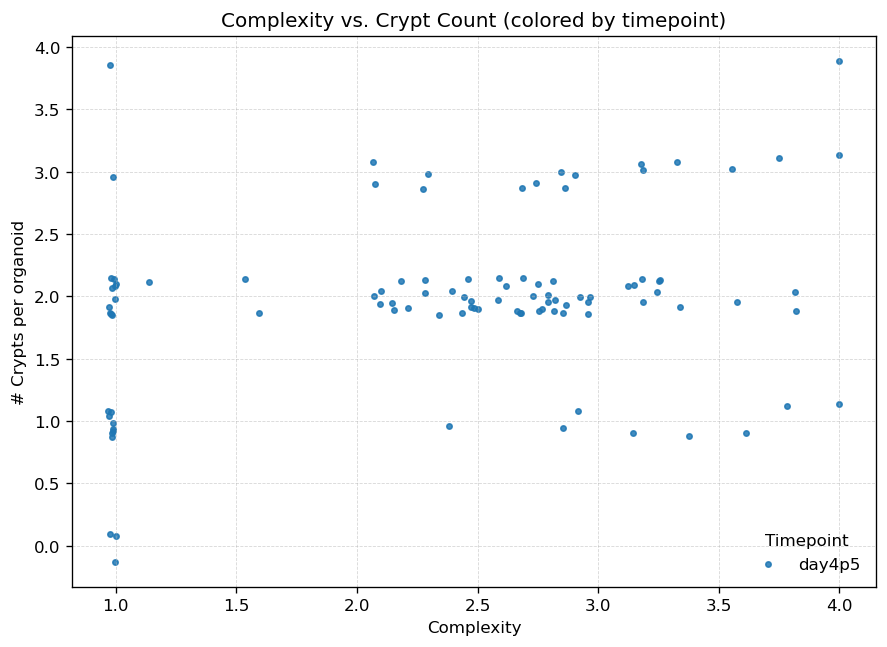

In [101]:
# Collect rows: one per organoid
recs = []
for tp, d in results.items():
    complexities = d.get("complexity", [])
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(complexities), len(crypts_all), len(labels))
    for i in range(n_items):
        cval = complexities[i]
        if cval is None or (isinstance(cval, float) and np.isnan(cval)):
            continue
        crypts_i = crypts_all[i]
        # crypts_i is typically a list (or list-like) of regions; fall back to 0 if None
        n_crypts = len(crypts_i) if crypts_i is not None else 0
        recs.append({
            "timepoint": tp,
            "complexity": float(cval),
            "n_crypts": int(n_crypts),
            "label_uid": labels[i]
        })

df = pd.DataFrame(recs)

# Build a consistent color per timepoint
unique_tps = sorted(df["timepoint"].unique())
cmap = plt.get_cmap("tab10")
color_map = {tp: cmap(i % 10) for i, tp in enumerate(unique_tps)}

plt.figure(figsize=(7.5, 5.5), dpi=120)
for tp in unique_tps:
    sub = df[df["timepoint"] == tp]
    n_crypts_jittered = sub["n_crypts"] + np.random.uniform(-0.15, 0.15, len(sub))

    plt.scatter(
        sub["complexity"],
        n_crypts_jittered,
        label=tp,
        alpha=0.85,
        s=10,
        c=[color_map[tp]]  # keep a single color per timepoint
    )

plt.xlabel("Complexity")
plt.ylabel("# Crypts per organoid")
plt.title("Complexity vs. Crypt Count (colored by timepoint)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(title="Timepoint", frameon=False)

plt.tight_layout()
plt.show()

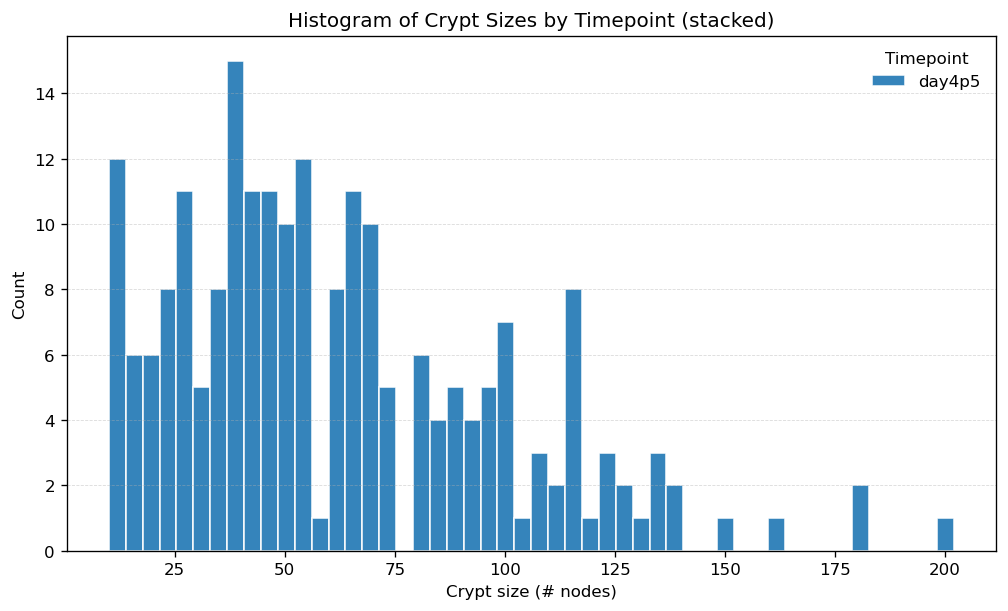

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame of crypt sizes (as you already did)
size_recs = []
for tp, d in results.items():
    crypts_all  = d.get("crypts_all", [])
    labels      = d.get("label_uid", [])
    n_items = min(len(crypts_all), len(labels))
    for i in range(n_items):
        crypts_i = crypts_all[i] or []
        for k, patch in enumerate(crypts_i):
            size_recs.append({
                "timepoint": tp,
                "label_uid": labels[i],
                "crypt_idx": k,
                "size": len(patch),
            })

sizes_df = pd.DataFrame(size_recs)
if sizes_df.empty:
    raise RuntimeError("No crypt sizes to plot.")

# Shared bin edges for all timepoints
bins = 50
bin_edges = np.histogram_bin_edges(sizes_df["size"].values, bins=bins)
bin_widths = np.diff(bin_edges)
bin_centers = bin_edges[:-1] + 0.5 * bin_widths

# Count per timepoint per bin
unique_tps = sorted(sizes_df["timepoint"].unique())
counts_per_tp = []
for tp in unique_tps:
    vals = sizes_df.loc[sizes_df["timepoint"] == tp, "size"].values
    counts, _ = np.histogram(vals, bins=bin_edges)
    counts_per_tp.append(counts)

# Plot stacked bars
plt.figure(figsize=(8.5, 5.2), dpi=120)
bottom = np.zeros_like(bin_centers, dtype=float)

cmap = plt.get_cmap("tab10")
for i, tp in enumerate(unique_tps):
    counts = counts_per_tp[i]
    plt.bar(
        bin_centers,
        counts,
        width=bin_widths,
        bottom=bottom,
        label=str(tp),
        edgecolor="white",
        alpha=0.9,
        align="center",
        color=cmap(i % 10),
    )
    bottom += counts

plt.xlabel("Crypt size (# nodes)")
plt.ylabel("Count")
plt.title("Histogram of Crypt Sizes by Timepoint (stacked)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.45)
plt.legend(title="Timepoint", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [103]:
import numpy as np

def plot_random_samples_by_filters(
    results,
    k=3,
    n_crypts=None,                 # e.g. 3 for exact match
    n_crypts_range=None,           # e.g. (2, 5) inclusive; ignored if n_crypts is set
    complexity_range=None,         # e.g. (0.2, 0.6) inclusive
    seed=None,
    node_size=2,
    colorscale='YlOrRd'
):
    """
    Pool across all timepoints, filter by #crypts and complexity, sample k organoids, and plot.

    Parameters
    ----------
    results : dict
        Your per-timepoint results structure.
    k : int
        Number of random samples to plot (pooled across timepoints).
    n_crypts : int or None
        Exact number of crypts to match. If provided, overrides n_crypts_range.
    n_crypts_range : (int, int) or None
        Inclusive range for number of crypts; ignored if n_crypts is not None.
    complexity_range : (float, float) or None
        Inclusive range for complexity. If None, no complexity filtering.
    seed : int or None
        Seed for reproducible sampling. If None, sampling is unseeded.
    node_size : int
        Passed to plot_organoid_graph.
    colorscale : str
        Passed to add_region_overlays for crypts overlay.
    """
    # Gather all candidates as (tp, idx) pairs after filtering
    candidates = []
    for tp, d in results.items():
        comp_arr   = d.get("complexity", [])
        crypts_all = d.get("crypts_all", [])
        N = min(len(comp_arr), len(crypts_all))
        for i in range(N):
            cval = comp_arr[i]
            if cval is None or (isinstance(cval, float) and np.isnan(cval)):
                continue

            n_cr = len(crypts_all[i]) if crypts_all[i] is not None else 0

            # Filter by number of crypts
            if n_crypts is not None:
                if n_cr != int(n_crypts):
                    continue
            elif n_crypts_range is not None:
                lo, hi = n_crypts_range
                if not (lo <= n_cr <= hi):
                    continue

            # Filter by complexity
            if complexity_range is not None:
                clo, chi = complexity_range
                if not (clo <= float(cval) <= chi):
                    continue

            candidates.append((tp, i))

    if not candidates:
        msg = "No organoids match the filters"
        parts = []
        if n_crypts is not None: parts.append(f"#crypts == {n_crypts}")
        elif n_crypts_range is not None: parts.append(f"{n_crypts_range[0]} ≤ #crypts ≤ {n_crypts_range[1]}")
        if complexity_range is not None: parts.append(f"{complexity_range[0]} ≤ complexity ≤ {complexity_range[1]}")
        if parts: msg += f" ({', '.join(parts)})."
        print(msg)
        return

    if seed is not None:
        np.random.seed(seed)

    choose_k = min(k, len(candidates))
    sel_idxs = np.random.choice(len(candidates), size=choose_k, replace=False)

    for j in sel_idxs:
        tp, i = candidates[j]
        d = results[tp]

        G = d['cell_graphs_all'][i]
        proj_points = np.array([G.nodes[n]["proj_point"] for n in G.nodes])
        HKS = np.array([G.nodes[n]["hks"] for n in G.nodes])

        fig = plot_organoid_graph(
            proj_points,
            G,
            HKS[:, 0],
            node_size=node_size
        )
        # crypts overlay
        add_region_overlays(fig, proj_points, d['crypts_all'][i], colorscale=colorscale)
        # villus overlay
        # add_region_overlays(fig, d['centroids_all'][i], [d['villus_all'][i]])

        # Optional: annotate for context
        try:
            cval = float(d['complexity'][i])
            n_cr = len(d['crypts_all'][i]) if d['crypts_all'][i] is not None else 0
            fig.update_layout(title=f"{d['label_uid'][i]} | complexity={cval:.3f}, #crypts={n_cr}")
        except Exception:
            pass

        fig.show()



# ---- Example calls ----
# Exact #crypts = 3, any complexity:
plot_random_samples_by_filters(results, k=3, n_crypts=3, complexity_range=(-1, 1))

# #crypts in [2,5] and complexity in [0.2, 0.6]:
# plot_random_samples_by_filters(results, k=4, n_crypts_range=(2,5), complexity_range=(0.2, 0.6))


In [104]:
# -------- settings --------
min_cells = 10                # ignore villi/crypts smaller than this
max_examples = 3             # cap the number of plots
seed = None                      # set to None for non-reproducible sampling
node_size = 2
villus_colorscale = 'Greens'
serotonin_color = 'magenta'
marker_name_serotonin = "Serotonin"

def _marker_index(names, target="Serotonin"):
    if names is None: 
        return None
    try:
        return names.index(target)
    except ValueError:
        for j, nm in enumerate(names):
            if isinstance(nm, str) and nm.lower() == target.lower():
                return j
    return None

# ---- 1) Collect all candidate villi: (tp, i, villus_indices, meta_info) ----
candidates = []
for tp, d in results.items():
    graphs_all    = d.get("cell_graphs_all", [])
    crypts_all    = d.get("crypts_all",   [])
    villus_all    = d.get("villus_all",   [])

    # normalize object arrays -> lists
    if isinstance(crypts_all, np.ndarray):    crypts_all    = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray):    villus_all    = villus_all.tolist()

    ser_idx = _marker_index(marker_names, marker_name_serotonin)
    if ser_idx is None:
        continue  # this timepoint has no serotonin marker

    n_items = len(graphs_all)
    for i in range(n_items):
        markers = np.array([graphs_all[i].nodes[n]["markers_bin"] for n in graphs_all[i].nodes])
        if markers is None:
            continue

        crypt_patches  = _to_patch_list(crypts_all[i]  if i < len(crypts_all)  else None)
        villus_patches = _to_patch_list(villus_all[i]  if i < len(villus_all)  else None)

        # filter by region size
        crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]
        villus_patches = [p for p in villus_patches if len(p) >= min_cells]

        if not crypt_patches or not villus_patches:
            continue  # require organoid to contain crypts and at least one villus

        for villus_patch in villus_patches:
            idx = np.fromiter(villus_patch, dtype=int)
            if idx.size == 0:
                continue
            ser_mask_villus = np.asarray(markers[idx, ser_idx], dtype=bool).reshape(-1)
            if np.any(ser_mask_villus):
                # store minimal info needed for plotting later
                meta = {
                    "tp": tp,
                    "org_idx": i,
                    "villus_size": int(idx.size),
                    "ser_count": int(np.count_nonzero(ser_mask_villus)),
                    "n_crypts": len(crypt_patches)
                }
                candidates.append( (tp, i, idx, meta) )

# ---- 2) Randomly sample up to max_examples and plot ----
if not candidates:
    print("No villi with Serotonin found in organoids that contain crypts (after filtering).")
else:
    if seed is not None:
        np.random.seed(seed)
    k = min(max_examples, len(candidates))
    sel = np.random.choice(len(candidates), size=k, replace=False)

    plotted = 0
    for j in sel:
        tp, i, idx, meta = candidates[j]
        d = results[tp]

        G = d['cell_graphs_all'][i]
        C = np.array([G.nodes[n]["proj_point"] for n in G.nodes])
        H = np.array([G.nodes[n]["hks"] for n in G.nodes])
        markers = np.array([G.nodes[n]["markers_bin"] for n in G.nodes])


        # rebuild serotonin mask (could also have saved it, but quick to recompute)
        ser_idx = _marker_index(marker_names, marker_name_serotonin)
        ser_mask_villus = np.asarray(markers[idx, ser_idx], dtype=bool).reshape(-1)
        idx_ser = idx[ser_mask_villus]

        # --- plot whole organoid ---
        fig = plot_organoid_graph(C, G, H[:,0], node_size=node_size)

        # highlight the selected villus
        add_region_overlays(fig, C, [idx.tolist()], colorscale=villus_colorscale)
        
        # highlight serotonin+ inside the villus
        fig.add_trace(
            go.Scatter3d(
                x=C[idx_ser, 0], y=C[idx_ser, 1], z=C[idx_ser, 2],
                mode="markers",
                marker=dict(size=node_size+3, color=serotonin_color),
                showlegend=True, hoverinfo="skip",
            )
        )

        # title / annotation
        fig.update_layout(
            title=f"{meta['tp']} | organoid #{meta['org_idx']} | #crypts={meta['n_crypts']} | villus size={meta['villus_size']} | serotonin+={meta['ser_count']}"
        )

        fig.show()
        plotted += 1

    print(f"Plotted {plotted} random villi with Serotonin (out of {len(candidates)} candidates).")


Plotted 3 random villi with Serotonin (out of 22 candidates).


## Analyse marker content of crypts

In [105]:
def get_marker_counts_per_patch(patch, markers):
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells

def split_villus_by_organoid(villus_patches, crypt_patches):
    """Return (villus_only, villus_with_crypts) as two lists of sets."""
    if crypt_patches and len(crypt_patches) > 0:
        return [], list(villus_patches)
    else:
        return list(villus_patches), []

def marker_coexpression(patch, bin_markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=1):
    idx = np.fromiter(patch, dtype=np.int64)
    bin_markers_patch = bin_markers[idx, :]

    coexpression = np.ndarray(4)
    has_marker = np.sum(bin_markers_patch, axis=0) >= pos_threshold

    coexpression[0] = has_marker[i_LGR5] and has_marker[i_Sero] and not has_marker[i_Lyso] 
    coexpression[1] = has_marker[i_LGR5] and has_marker[i_Lyso] and not has_marker[i_Sero]
    coexpression[2] = has_marker[i_LGR5] and (has_marker[i_Lyso] or has_marker[i_Sero]) 
    coexpression[3] = has_marker[i_LGR5] and (has_marker[i_Lyso] and has_marker[i_Sero])
    # coexpression[4] = has_marker[i_LGR5] and not has_marker[i_Lyso] and not has_marker[i_Sero] 

    return coexpression.astype(np.int64)


# --- configuration ---
min_positive = 1

# --- aggregate across all timepoints/organoids ---

num_crypts = np.zeros(len(timepoints), dtype=np.int64)
num_villus = np.zeros(len(timepoints), dtype=np.int64)
num_single = np.zeros(len(timepoints), dtype=np.int64)
marker_pos_crypt = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
marker_pos_villus = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
marker_pos_single = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)

num_pos_cells_crypt = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_pos_cells_villus = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_pos_cells_single = np.zeros((len(timepoints), len(marker_names)), dtype=np.int64)
num_cells_crypt = np.zeros(len(timepoints), dtype=np.int64)
num_cells_villus = np.zeros(len(timepoints), dtype=np.int64)
num_cells_single = np.zeros(len(timepoints), dtype=np.int64)


coexpression_crypt = np.zeros((len(timepoints), 4))
coexpression_villus = np.zeros((len(timepoints), 4))
coexpression_single = np.zeros((len(timepoints), 4))


j = -1
for tp, d in results.items(): # loop over timepoints
    graphs_all   = d.get("cell_graphs_all", [])
    crypts_all   = d.get("crypts_all",   [])
    villus_all   = d.get("villus_all",   [])

    i_LGR5 = marker_names.index("LGR5")  # raises ValueError if not found
    i_Sero = marker_names.index("Serotonin")  # raises ValueError if not found
    i_Lyso = marker_names.index("Lysozyme")  # raises ValueError if not found

    j += 1

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    n_items = len(graphs_all)
    for i in range(n_items): # loop over organoids in timepoint
        markers = np.array([graphs_all[i].nodes[n]["markers_bin"] for n in graphs_all[i].nodes])
        
        if markers is None:
            continue

        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = _to_patch_list(villus_all[i] if i < len(villus_all) else None)

        # (OPTIONAL) filter out regions with too few cells
        crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]
        villus_patches = [p for p in villus_patches if len(p) >= min_cells]


        villus_only, villus_with = split_villus_by_organoid(villus_patches, crypt_patches)

        # --- CRYPTS (patch-wise + cell-wise) ---
        for patch in crypt_patches:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_crypt[j] += num_cells
            num_pos_cells_crypt[j,:] += num_pos_cells
            marker_pos_crypt[j,:] += (num_pos_cells >= min_positive) 
            num_crypts[j] += 1
            coexpression_crypt[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)


        # --- VILLUS WITH CRYPTS---
        for patch in villus_with:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_villus[j] += num_cells
            num_pos_cells_villus[j,:] += num_pos_cells
            marker_pos_villus[j,:] += (num_pos_cells >= min_positive) 
            num_villus[j] += 1
            coexpression_villus[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)


        # --- VILLUS WITHOUT CRYPTS---
        for patch in villus_only:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_single[j] += num_cells
            num_pos_cells_single[j,:] += num_pos_cells
            marker_pos_single[j,:] += (num_pos_cells >= min_positive) 
            num_single[j] += 1
            coexpression_single[j,:] += marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso)



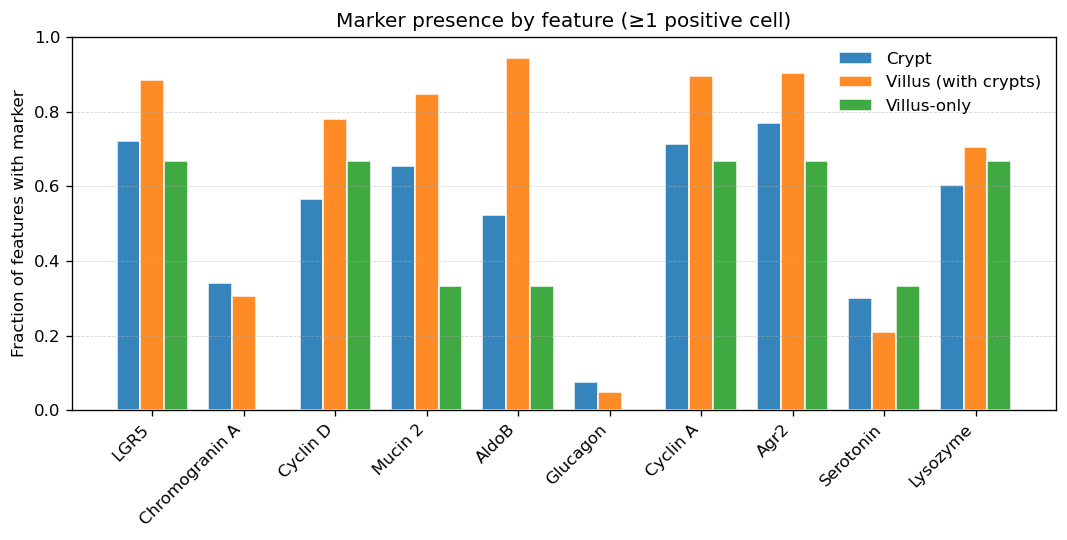

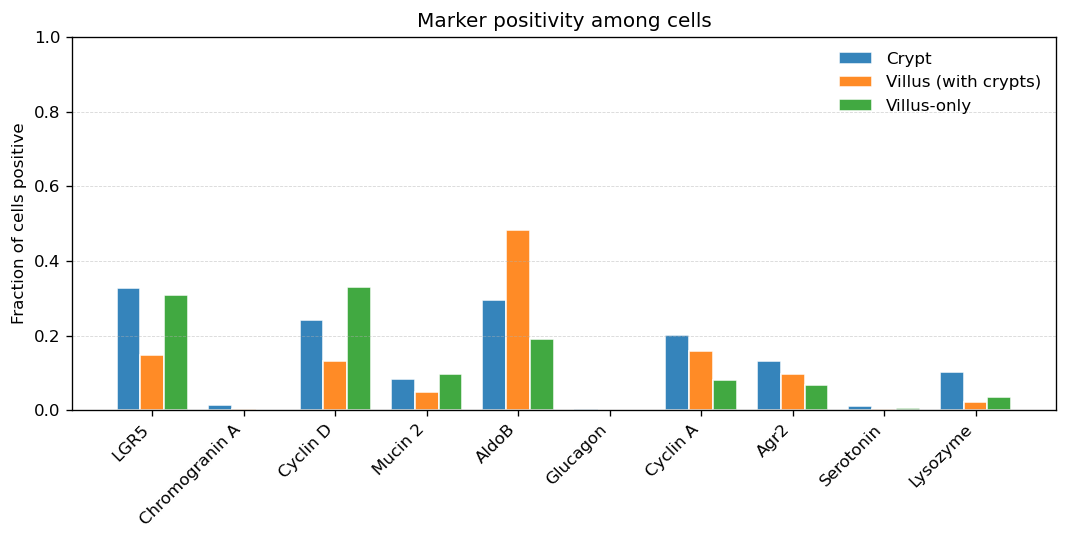

In [106]:
# --- Plotting: grouped bars with three categories ---

def _plot_grouped_bars_3(crypt_vals, villus_with_vals, villus_only_vals, ylabel, title):
    m = len(marker_names)
    x = np.arange(m)
    w = 0.26

    plt.figure(figsize=(max(9, 0.5*m), 4.6), dpi=120)
    plt.bar(x - w,      crypt_vals,        width=w, label="Crypt",               edgecolor="white", alpha=0.9)
    plt.bar(x,          villus_with_vals,  width=w, label="Villus (with crypts)",edgecolor="white", alpha=0.9)
    plt.bar(x + w,      villus_only_vals,  width=w, label="Villus-only",         edgecolor="white", alpha=0.9)
    plt.xticks(x, marker_names, rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Figure 1
_plot_grouped_bars_3(
    np.sum(marker_pos_crypt, axis=0)/np.sum(num_crypts),
    np.sum(marker_pos_villus, axis=0)/np.sum(num_villus),
    np.sum(marker_pos_single, axis=0)/np.sum(num_single),
    ylabel="Fraction of features with marker",
    title=f"Marker presence by feature (≥{min_positive} positive cell)"
)

# Figure 2
_plot_grouped_bars_3(
    np.sum(num_pos_cells_crypt, axis=0)/np.sum(num_cells_crypt),
    np.sum(num_pos_cells_villus, axis=0)/np.sum(num_cells_villus),
    np.sum(num_pos_cells_single, axis=0)/np.sum(num_cells_single),
    ylabel="Fraction of cells positive",
    title="Marker positivity among cells"
)


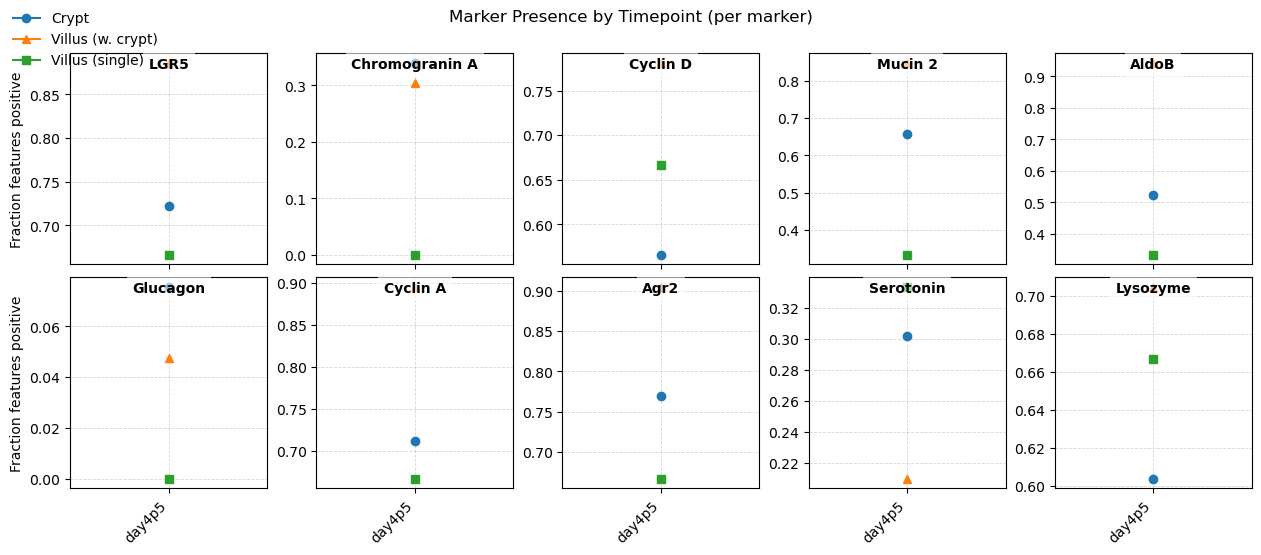

In [107]:
x = np.arange(len(timepoints))
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(x, marker_pos_crypt[:,i]/num_crypts, marker='o', label='Crypt')
    ax.plot(x, marker_pos_villus[:,i]/num_villus, marker='^', label='Villus (w. crypt)')
    ax.plot(x, marker_pos_single[:,i]/num_single, marker='s', label='Villus (single)')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")

    # y-label only on leftmost column
    if c == 0:
        ax.set_ylabel("Fraction features positive")

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)
    for rr in range(n_rows):
        for cc in range(n_cols):
            if axes[rr, cc].get_visible():
                handles, labels = axes[rr, cc].get_legend_handles_labels()
                break
        else:
            continue
        break


fig.legend(handles, labels, loc="upper left", ncol=1, frameon=False)
fig.suptitle("Marker Presence by Timepoint (per marker)", y=1.08, fontsize=12)
plt.show()

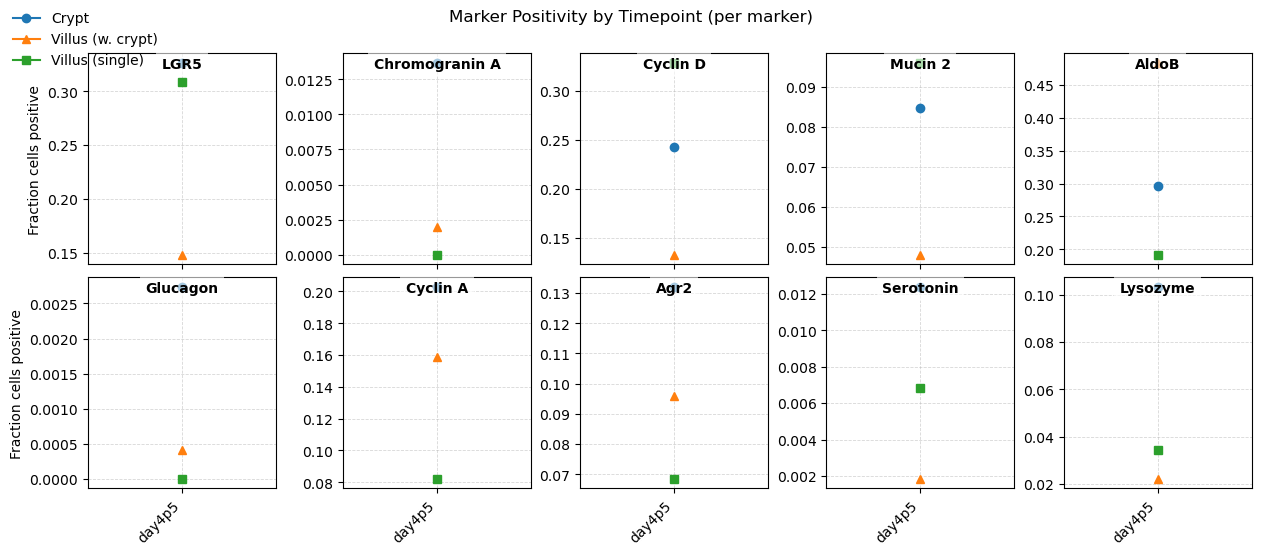

In [108]:
x = np.arange(len(timepoints))
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(x, num_pos_cells_crypt[:,i]/num_cells_crypt, marker='o', label='Crypt')
    ax.plot(x, num_pos_cells_villus[:,i]/num_cells_villus, marker='^', label='Villus (w. crypt)')
    ax.plot(x, num_pos_cells_single[:,i]/num_cells_single, marker='s', label='Villus (single)')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")

    # y-label only on leftmost column
    if c == 0:
        ax.set_ylabel("Fraction cells positive")

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)
    for rr in range(n_rows):
        for cc in range(n_cols):
            if axes[rr, cc].get_visible():
                handles, labels = axes[rr, cc].get_legend_handles_labels()
                break
        else:
            continue
        break


fig.legend(handles, labels, loc="upper left", ncol=1, frameon=False)
fig.suptitle("Marker Positivity by Timepoint (per marker)", y=1.08, fontsize=12)
plt.show()

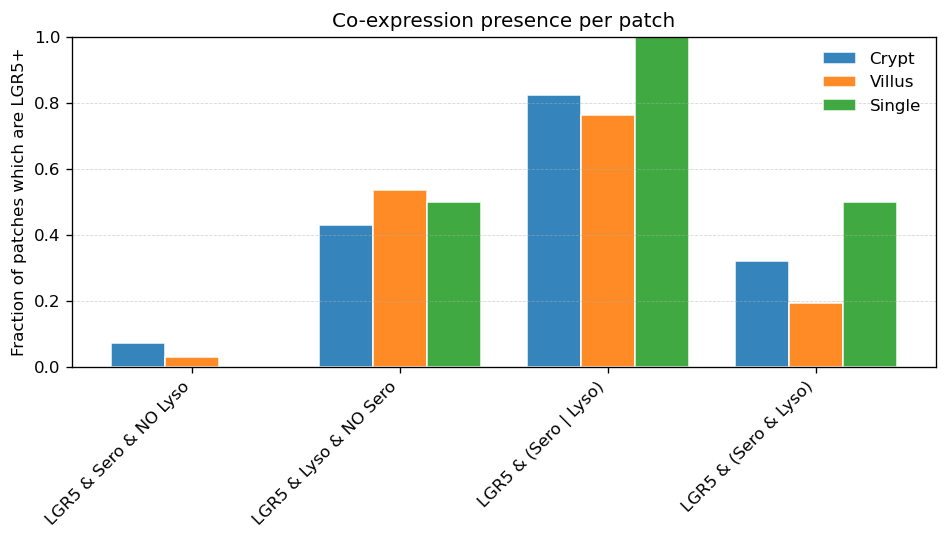

In [109]:
# --- Fractions per condition ---
labels_cond = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
]


# --- Plot grouped bars (crypt vs villus) ---
x = np.arange(len(labels_cond))
w = 0.26

plt.figure(figsize=(max(8, 0.6*len(labels_cond)), 4.6), dpi=120)
plt.bar(x - w, np.sum(coexpression_crypt, axis=0)/np.sum(marker_pos_crypt[:,i_LGR5], axis=0),  width=w, label="Crypt",  edgecolor="white", alpha=0.9)
plt.bar(x , np.sum(coexpression_villus, axis=0)/np.sum(marker_pos_villus[:,i_LGR5], axis=0), width=w, label="Villus", edgecolor="white", alpha=0.9)
plt.bar(x + w, np.sum(coexpression_single, axis=0)/np.sum(marker_pos_single[:,i_LGR5], axis=0), width=w, label="Single", edgecolor="white", alpha=0.9)
plt.xticks(x, labels_cond, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Fraction of patches which are LGR5+")
plt.title("Co-expression presence per patch")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

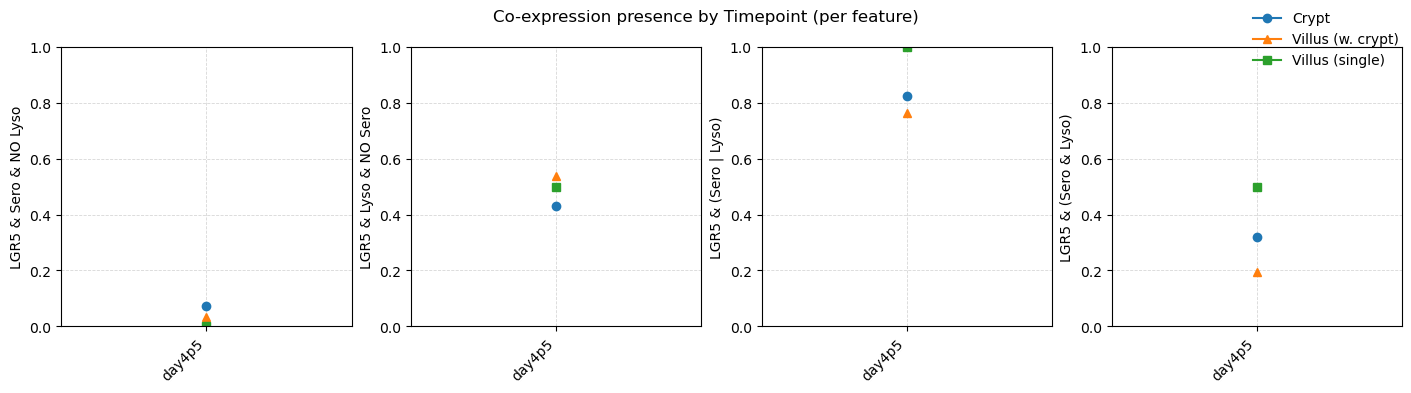

In [110]:
x = np.arange(len(timepoints))
n_cols = 4
n_rows = int(np.ceil(len(labels_cond) / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.5 * n_cols, 3.5 * n_rows),
        sharex=True, sharey=False,
        constrained_layout=True
    )

for i in range(len(labels_cond)):

    ax = axes[i]

    ax.plot(x, coexpression_crypt[:,i]/marker_pos_crypt[:,i_LGR5], marker='o', label='Crypt')
    ax.plot(x, coexpression_villus[:,i]/marker_pos_villus[:,i_LGR5], marker='^', label='Villus (w. crypt)')
    ax.plot(x, coexpression_single[:,i]/marker_pos_single[:,i_LGR5], marker='s', label='Villus (single)')

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # x ticks = timepoints (rotate for readability)
    ax.set_xticks(x)
    ax.set_xticklabels(timepoints, rotation=45, ha="right")
    ax.set_ylabel(labels_cond[i])
    ax.set_ylim([0, 1])

    # Single, figure-level legend
    # (grab handles/labels from the first visible axis)

    handles, labels = axes[i].get_legend_handles_labels()


fig.legend(handles, labels, loc="upper right", ncol=1, frameon=False)
fig.suptitle("Co-expression presence by Timepoint (per feature)", y=1.08, fontsize=12)
plt.show()

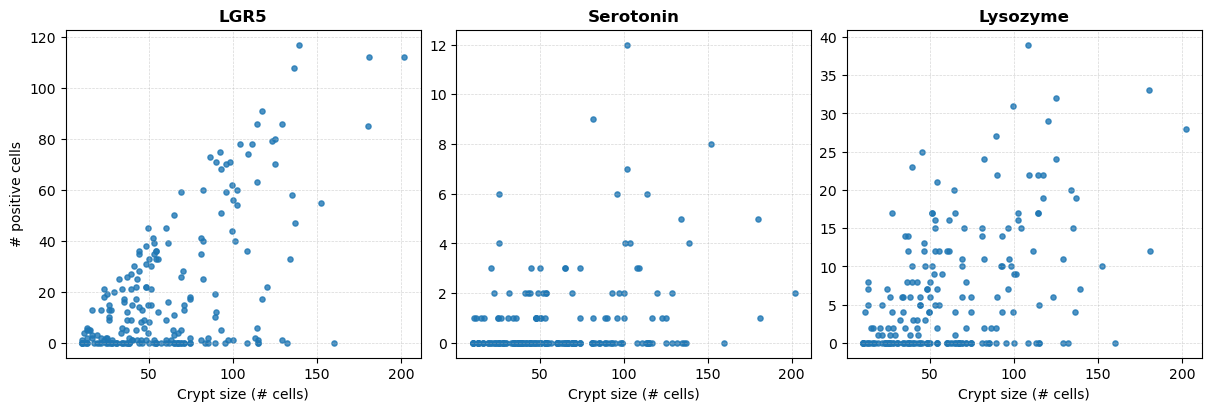

In [111]:
def get_marker_counts_per_patch(patch, markers):
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells

def split_villus_by_organoid(villus_patches, crypt_patches):
    """Return (villus_only, villus_with_crypts) as two lists of sets."""
    if crypt_patches and len(crypt_patches) > 0:
        return [], list(villus_patches)
    else:
        return list(villus_patches), []

# --- configuration ---
min_positive = 2

# --- aggregate across all timepoints/organoids ---
num_pos_cells_crypt_all = []
num_cells_crypt_all = []

for tp, d in results.items(): # loop over timepoints
    graphs_all   = d.get("cell_graphs_all", [])
    crypts_all   = d.get("crypts_all",   [])
    villus_all   = d.get("villus_all",   [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_items = len(graphs_all)
    for i in range(n_items): # loop over organoids in timepoint
        markers = np.array([graphs_all[i].nodes[n]["markers_bin"] for n in graphs_all[i].nodes])
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)

        # (OPTIONAL) filter out regions with too few cells
        crypt_patches  = [p for p in crypt_patches  if len(p) >= min_cells]

        for patch in crypt_patches:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)
            
            num_cells_crypt_all.append(num_cells)
            num_pos_cells_crypt_all.append(num_pos_cells)


# Stack to (n_crypts, n_markers)
pos_mat = np.vstack([np.asarray(v, dtype=int) for v in num_pos_cells_crypt_all])  # each v is a vector per crypt
sizes   = np.asarray(num_cells_crypt_all, dtype=int)                               # (n_crypts,)

markers = [("LGR5", i_LGR5), ("Serotonin", i_Sero), ("Lysozyme", i_Lyso)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=False)

for ax, (name, idx) in zip(axes, markers):
    y = pos_mat[:, idx]
    ax.scatter(sizes, y, s=14, alpha=0.8)
    # y = x reference line
    ax.set_title(name, fontweight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

axes[0].set_ylabel("# positive cells")
for ax in axes:
    ax.set_xlabel("Crypt size (# cells)")

plt.show()


## Spatially resolved marker composition in crypts

In [120]:
data_dir = '../NicoleData/20250929/fractal_output'

timepoints = ['day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']   # extend as needed: ['day3', 'day3p5', ...]
zarr_names = {tp: 'r0.zarr' for tp in timepoints}
rounds     = {tp: '0_fused_zillum_registered' for tp in timepoints}
meshes     = {tp: 'nnorg_linked_multi_annotated_class' for tp in timepoints}

wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

def mesh_path_from_label_uid(label_uid):
    """
    Reconstruct the .vtp mesh path from a label_uid of the form
    '{tp}_{well}_{organoid_id}'.

    This assumes the same directory layout as in preprocess_organoid_graphs.py.
    """
    parts = label_uid.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected label_uid format: {label_uid}")

    tp   = parts[0]
    well = parts[1]
    organoid_id = "_".join(parts[2:])  # in case organoid_id itself has underscores

    plate = well[0]
    field = well[1:]

    zarr_name  = zarr_names[tp]
    round_name = rounds[tp]
    mesh_name  = meshes[tp]

    base_dir = os.path.join(data_dir, tp, zarr_name, plate, field, round_name)
    mesh_dir = os.path.join(base_dir, "meshes", mesh_name)
    mesh_path = os.path.join(mesh_dir, f"{organoid_id}.vtp")

    return mesh_path



def _crypt_bottom_index(HKS, t_HKS, crypt_nodes):
    """Pick node in crypt with max mean HKS across selected time indices."""
    idx = np.fromiter(crypt_nodes, dtype=int)
    z = HKS[idx,:]*t_HKS                   
    agg = np.nanmean(z, axis=1)                  # simple, robust aggregate
    return int(idx[np.nanargmax(agg)])

def _neck_nodes_for_crypt(G, crypt_nodes, neck_patches):
    """
    Return ONLY those neck nodes that form the boundary between this crypt and the neck.

    Concretely: neck cells that are 1-hop neighbors of any crypt cell.
    This gives you a "ring" of neck cells around the crypt opening.
    """

    # collect neighbors of crypt (1-hop shell)
    crypt_neighbors = set()
    for u in crypt_nodes:
        crypt_neighbors.update(G.neighbors(u))

    boundary = set()
    for neck in neck_patches:
        # neck patch that touches this crypt
        if neck & crypt_neighbors:
            # only take neck cells that are direct neighbors of the crypt
            boundary |= (neck & crypt_neighbors)

    return boundary



def _bin_marker_positivity(markers, dnorm, bin_edges):
    """
    Bin marker positivity across the ENTIRE organoid by normalized distance.

    Parameters
    ----------
    markers : (N, M) array-like (bool/int)
        Per-cell marker matrix (True/1 = positive). N cells, M markers.
    dnorm : (N,) array-like (float)
        Normalized distance for each cell (e.g., distance from bottom / distance to nearest neck).
        Can include values >1 if you want neck/villus in the same histogram.
    bin_edges : (K+1,) array-like (float)
        Bin edges for np.digitize (e.g., np.linspace(0, 1.0, 11)).

    Returns
    -------
    counts_pos  : (M, K) float array  (number of positive cells per marker in each bin)
    counts_total: (K,) int array      (number of cells in each bin)
    """

    if markers.ndim != 2:
        raise ValueError("markers must be a 2D array (N, M).")
    if dnorm.ndim != 1 or dnorm.shape[0] != markers.shape[0]:
        raise ValueError("dnorm must be 1D with length N (same N as markers).")

    N, M = markers.shape
    nb = len(bin_edges) - 1

    # Assign bins (0..nb-1)
    bin_ids = np.digitize(dnorm, bin_edges) - 1

    counts_pos = np.zeros((M, nb), dtype=np.int64)
    counts_total = np.zeros(nb, dtype=np.int64)

    # Loop bins; ignore out-of-range ids (<0 or >=nb)
    for b in range(nb):
        mask = (bin_ids == b)
        if not np.any(mask):
            continue


        counts_total[b] = np.sum(mask)
        block = markers[mask, :].astype(bool)   
        counts_pos[:, b] = np.sum(block, axis=0)   

    return counts_pos, counts_total



def _normalized_distance_to_bottom(mesh, G, bottom_idx, neck_nodes):
    """
    Compute normalized crypt-bottom distances at CELL level, using
    full-resolution vertex geodesics on the membrane mesh.

    Parameters
    ----------
    mesh : OrganoidMesh
        Mesh for this organoid (geometry only is enough).
    G : networkx.Graph
        Cell graph for this organoid. Nodes must have 'proj_vertex' attributes.
    bottom_idx : int
        Index of the bottom cell in this crypt (node index in G).
    neck_nodes : set of int
        Cell indices for neck/villus cells touching this crypt
        (e.g. from _neck_nodes_for_crypt).

    Returns
    -------
    dist_norm_cells : (N_cells,) ndarray
        Normalized distance to crypt bottom for each cell in the organoid.
        - 0 at the bottom cell
        - ~1 at the local neck boundary
        - >1 for positions beyond the neck (e.g. further up the villus)
    """

    if len(neck_nodes) == 0:
        raise ValueError("neck_nodes is empty; cannot normalize distances.")

    # --- 1) Map bottom & neck cells to their projected vertices ---
    bottom_vertex = int(G.nodes[bottom_idx]["proj_vertex"])

    neck_vertex_ids = np.fromiter(
        (int(G.nodes[n]["proj_vertex"]) for n in neck_nodes),
        dtype=np.int64,
    )
    neck_vertex_ids = np.unique(neck_vertex_ids)  # avoid duplicate sources

    # --- 2) Geodesics from bottom + neck vertices on the mesh ---
    # sources[0] = bottom vertex, sources[1:] = neck boundary vertices
    sources = np.concatenate([[bottom_vertex], neck_vertex_ids])
    # D has shape (1 + n_neck_vertices, V)

    D = compute_geodesics(mesh, t=None, sources=sources)

    D_bottom = D[0]          # (V,) distance from bottom to every vertex
    D_neck   = D[1:, :]      # (n_neck, V) distance from each neck vertex



    import plotly.graph_objects as go
    fig = go.Figure(
            data=[
                go.Mesh3d(
                    x=mesh.v[:, 0],
                    y=mesh.v[:, 1],
                    z=mesh.v[:, 2],
                    i=mesh.f[:, 0],
                    j=mesh.f[:, 1],
                    k=mesh.f[:, 2],
                    intensity=D_bottom,
                    colorscale="Viridis",
                    showscale=True,
                    name="Normalized crypt-bottom distance",
                )
            ]
        )
    # Highlight neck vertices as red points
    fig.add_trace(
            go.Scatter3d(
                x=mesh.v[neck_vertex_ids, 0],
                y=mesh.v[neck_vertex_ids, 1],
                z=mesh.v[neck_vertex_ids, 2],
                mode="markers",
                marker=dict(size=4, color="red"),
                name="Neck vertices"
            )
        )
    
    fig.update_layout(
        title="Organoid mesh colored by normalized crypt-bottom distance",
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode="data",
        ),
    )
    fig.show()


    # --- 3) For each vertex, find the nearest neck vertex ---
    # closest_neck_idx[v] gives index (0..n_neck-1) of the closest neck vertex
    closest_neck_idx = np.argmin(D_neck, axis=0)          # (V,)
    # map that to absolute neck vertex id
    neck_for_vertex = neck_vertex_ids[closest_neck_idx]   # (V,)

    # crypt length for each vertex = distance from bottom to its nearest neck vertex
    crypt_length_vertex = D_bottom[neck_for_vertex]       # (V,)

    # guard against zero / very small crypt length
    eps = 1e-8
    crypt_length_vertex = np.maximum(crypt_length_vertex, eps)

    # --- 4) Normalized distance per vertex ---
    dnorm_vertex = D_bottom / crypt_length_vertex   # (V,)

    # --- 5) Sample per-cell distances at each cell's projected vertex ---
    n_cells = G.number_of_nodes()
    dist_norm_cells = np.zeros(n_cells, dtype=float)

    for c in range(n_cells):
        v_id = int(G.nodes[c]["proj_vertex"])
        dist_norm_cells[c] = dnorm_vertex[v_id]

    return dist_norm_cells


In [121]:
# Config
bin_edges   = np.linspace(0.0, 1.4, 20)
bin_centers = 0.5 * (np.asarray(bin_edges[:-1]) + np.asarray(bin_edges[1:]))

M      = len(marker_names)
n_tp   = len(timepoints)
n_bins = len(bin_centers)

num_pos_per_bin   = np.zeros((n_tp, M, n_bins))   # [time, marker, bin]
num_cells_per_bin = np.zeros((n_tp, n_bins))      # [time, bin]

crypt_counts_pos = [[] for _ in range(n_tp)]
crypt_counts_tot = [[] for _ in range(n_tp)]

j = -1  # time index

for tp, d in results.items():
    j += 1

    crypts_all  = d.get("crypts_all", [])
    villus_all  = d.get("villus_all", [])
    Gs          = d.get("cell_graphs_all", [])
    label_uids  = d.get("label_uid", [])

    # Defensive: ensure Python lists
    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    n_items = len(Gs)

    for i in range(1): #range(n_items):
        G = Gs[i]
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        neck_patches  = _to_patch_list(villus_all[i] if i < len(villus_all) else None)

        if not crypt_patches:
            continue

        # --- reconstruct HKS + markers from graph nodes ---
        n_cells = G.number_of_nodes()
        # assume nodes are 0..N-1
        HKS = np.vstack([np.asarray(G.nodes[n]["hks"]) for n in range(n_cells)])
        markers = np.array([G.nodes[n]["markers_bin"] for n in G.nodes])

        # HKS times (used as t_HKS weighting)
        t_HKS = np.asarray(G.graph.get("hks_times"))

        # --- load mesh for this organoid ---
        label_uid = label_uids[i]
        try:
            mesh_path = mesh_path_from_label_uid(label_uid)
        except Exception as e:
            print(f"Could not reconstruct mesh path for {label_uid}: {e}")
            continue

        if not os.path.exists(mesh_path):
            print(f"Mesh file not found for {label_uid}: {mesh_path}")
            continue

        mesh = OrganoidMesh(mesh_path)
        mesh._eig_decomp()

        # --- process each crypt separately and aggregate ---
        for crypt in crypt_patches:

            # 1) bottom of crypt (in CELL space)
            bottom = _crypt_bottom_index(HKS, t_HKS, crypt)

            # 2) neck ring cells for this crypt
            neck_nodes = _neck_nodes_for_crypt(G, crypt, neck_patches)
            if len(neck_nodes) == 0:
                continue

            # 3) normalized distance (bottom -> neck is 1), computed via vertex geodesics
            dist_norm_cells = _normalized_distance_to_bottom(mesh, G, bottom, neck_nodes)

            # 4) bin marker positivity across normalized distance (per cell)
            counts_pos, counts_total = _bin_marker_positivity(
                markers,
                dist_norm_cells,
                bin_edges
            )

            # accumulate weighted by counts
            num_pos_per_bin[j]   += counts_pos
            num_cells_per_bin[j] += counts_total

            crypt_counts_pos[j].append(counts_pos)
            crypt_counts_tot[j].append(counts_total)


heat sources: 100%|██████████| 26/26 [00:00<00:00, 211.75it/s]


heat sources: 100%|██████████| 19/19 [00:00<00:00, 122.97it/s]


In [114]:
# def _crypt_bottom_index(HKS, t_HKS, crypt_nodes):
#     """Pick node in crypt with max mean HKS across selected time indices."""
#     idx = np.fromiter(crypt_nodes, dtype=int)
#     z = HKS[idx,:]*t_HKS                   
#     agg = np.nanmean(z, axis=1)                  # simple, robust aggregate
#     return int(idx[np.nanargmax(agg)])

# def _neck_nodes_for_crypt(G, crypt_nodes, neck_patches):
#     """
#     Return all neck nodes from neck_patches that touch this crypt:
#       - overlap with crypt nodes, or
#       - are 1-hop neighbors of any crypt node.
#     """

#     # collect neighbors of crypt (1-hop shell)
#     crypt_neighbors = set()
#     for u in crypt_nodes:
#         crypt_neighbors.update(G.neighbors(u))

#     touching = set()
#     for neck in neck_patches:
#         # include neck nodes that overlap with crypt (defensive) or touch via an edge
#         if (neck & crypt_nodes) or (neck & crypt_neighbors):
#             touching |= neck

#     return touching


# # def _normalized_distance_to_bottom(geo, bottom_idx, neck_nodes):
# #     """
# #     geo: (N,N) geodesic matrix for this organoid
# #     bottom_idx: int (bottom cell)
# #     neck_nodes: set of ints (ring candidates)
# #     Return: distance to bottom cell in units of crypt length.
# #     """

# #     neck_idx = np.fromiter(neck_nodes, dtype=int)
# #     crypt_length = np.mean(geo[bottom_idx, neck_idx]) # for now, take the mean
# #     dist_to_bottom = geo[bottom_idx, :]/crypt_length
# #     return dist_to_bottom


# def _normalized_distance_to_bottom(geo, bottom_idx, neck_nodes):
#     """
#     geo: (N,N) geodesic matrix for this organoid
#     bottom_idx: int (bottom cell)
#     neck_nodes: set of ints (ring candidates)
#     Return: distance to bottom cell in units of crypt length.
#     """

#     neck_idx = np.fromiter(neck_nodes, dtype=int)
#     closest_neck = np.argmin( geo[neck_idx, :], axis=0) # index closest neck node
#     dist_bottom = geo[bottom_idx, :] # distance to crypt bottom

#     # "crypt length" varies, if neck is on the side of the crypt.
#     # Define crypt length wrt. closest neck cell
#     crypt_length = dist_bottom[closest_neck]

#     return dist_bottom/crypt_length


# def _bin_marker_positivity(markers, dnorm, bin_edges):
#     """
#     Bin marker positivity across the ENTIRE organoid by normalized distance.

#     Parameters
#     ----------
#     markers : (N, M) array-like (bool/int)
#         Per-cell marker matrix (True/1 = positive). N cells, M markers.
#     dnorm : (N,) array-like (float)
#         Normalized distance for each cell (e.g., distance from bottom / distance to nearest neck).
#         Can include values >1 if you want neck/villus in the same histogram.
#     bin_edges : (K+1,) array-like (float)
#         Bin edges for np.digitize (e.g., np.linspace(0, 1.0, 11)).

#     Returns
#     -------
#     counts_pos  : (M, K) float array  (number of positive cells per marker in each bin)
#     counts_total: (K,) int array      (number of cells in each bin)
#     """

#     if markers.ndim != 2:
#         raise ValueError("markers must be a 2D array (N, M).")
#     if dnorm.ndim != 1 or dnorm.shape[0] != markers.shape[0]:
#         raise ValueError("dnorm must be 1D with length N (same N as markers).")

#     N, M = markers.shape
#     nb = len(bin_edges) - 1

#     # Assign bins (0..nb-1)
#     bin_ids = np.digitize(dnorm, bin_edges) - 1

#     counts_pos = np.zeros((M, nb), dtype=np.int64)
#     counts_total = np.zeros(nb, dtype=np.int64)

#     # Loop bins; ignore out-of-range ids (<0 or >=nb)
#     for b in range(nb):
#         mask = (bin_ids == b)
#         if not np.any(mask):
#             continue


#         counts_total[b] = np.sum(mask)
#         block = markers[mask, :].astype(bool)   
#         counts_pos[:, b] = np.sum(block, axis=0)   

#     return counts_pos, counts_total


# # =========================
# # MAIN ANALYSIS LOOP (aggregated across organoids)
# # =========================

# # Config
# bin_edges = np.linspace(0.0, 1.4, 20)      # normalized distance bins (0..1)
# bin_centers = 0.5 * (np.asarray(bin_edges[:-1]) + np.asarray(bin_edges[1:]))

# M = len(marker_names)
# n_tp = len(timepoints)
# n_bins = len(bin_centers)

# # Accumulate numerators/denominators per bin across crypts to get a robust curve
# num_pos_per_bin = np.zeros((n_tp, M, n_bins))   # [time, marker, bin]
# num_cells_per_bin = np.zeros((n_tp, n_bins))    # [time, bin]

# # store per-crypt counts for bootstrapping
# crypt_counts_pos = [[] for _ in range(n_tp)]    # each element: list of arrays (M, n_bins)
# crypt_counts_tot = [[] for _ in range(n_tp)]    # each element: list of arrays (n_bins,)

# j = -1

# for tp, d in results.items():
#     HKS_all       = d.get("HKS_all",       np.array([], dtype=object))
#     crypts_all    = d.get("crypts_all",    [])
#     necks_all     = d.get("necks_all",     None)  # optional
#     markers_all   = d.get("markers_all",   np.array([], dtype=object))
#     geodesic_all  = d.get("dist_heat_all", np.array([], dtype=object))  # (N,N) per organoid
#     Gs            = d.get("cell_graphs_all", [])

#     j += 1  # time index

#     if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
#     if isinstance(necks_all, np.ndarray): necks_all = necks_all.tolist()

#     n_items = len(HKS_all)
#     for i in range(n_items):  # loop over organoids
#         HKS = HKS_all[i]
#         markers = markers_all[i]
#         geo = geodesic_all[i]
#         G = Gs[i]

#         crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
#         neck_patches  = _to_patch_list(necks_all[i] if i < len(necks_all) else None)

#         if not crypt_patches:
#             continue

#         # process each crypt separately and aggregate
#         for crypt in crypt_patches:

#             # 1) bottom of crypt
#             bottom = _crypt_bottom_index(HKS, t_HKS, crypt)

#             # 2) neck ring for this crypt
#             neck_nodes = _neck_nodes_for_crypt(G, crypt, neck_patches)
#             if len(neck_nodes) == 0:
#                 continue

#             # 3) normalized distance (bottom -> neck is 1)
#             dist_norm = _normalized_distance_to_bottom(geo, bottom, neck_nodes)

#             # 4) bin marker positivity across normalized distance
#             counts_pos, counts_total = _bin_marker_positivity(markers, dist_norm, bin_edges)
#             # counts_pos: (M, n_bins)
#             # counts_total: (n_bins,)

#             # accumulate weighted by counts
#             num_pos_per_bin[j]   += counts_pos
#             num_cells_per_bin[j] += counts_total

#             # store for bootstrap
#             crypt_counts_pos[j].append(counts_pos)
#             crypt_counts_tot[j].append(counts_total)


# # ----------------------------------------------------------
# # Bootstrap errorbars per timepoint, marker, and distance bin
# # ----------------------------------------------------------
# n_boot = 1000  # number of bootstrap resamples

# # Empirical fraction (from full aggregated counts)
# with np.errstate(divide='ignore', invalid='ignore'):
#     frac_empirical = num_pos_per_bin / num_cells_per_bin[:, None, :]

# # brute-force masking per time:
# for t in range(n_tp):
#     zero_bins = (num_cells_per_bin[t] == 0)
#     frac_empirical[t, :, zero_bins] = np.nan


# # Allocate arrays for bootstrap CIs
# frac_boot_mean  = np.full_like(frac_empirical, np.nan, dtype=float)
# frac_boot_lower = np.full_like(frac_empirical, np.nan, dtype=float)
# frac_boot_upper = np.full_like(frac_empirical, np.nan, dtype=float)

# for t_idx in range(n_tp):
#     if len(crypt_counts_pos[t_idx]) == 0:
#         continue  # no data at this timepoint

#     pos_arr = np.stack(crypt_counts_pos[t_idx], axis=0)  # (n_crypts, M, n_bins)
#     tot_arr = np.stack(crypt_counts_tot[t_idx], axis=0)  # (n_crypts, n_bins)
#     n_crypts = pos_arr.shape[0]

#     # store bootstrap means: (n_boot, M, n_bins)
#     boot_means = np.empty((n_boot, M, n_bins), dtype=float)

#     for b in range(n_boot):
#         # sample crypt indices with replacement
#         idx = np.random.randint(0, n_crypts, size=n_crypts)

#         pos_b = pos_arr[idx].sum(axis=0)   # (M, n_bins)
#         tot_b = tot_arr[idx].sum(axis=0)   # (n_bins,)

#         with np.errstate(divide='ignore', invalid='ignore'):
#             frac_b = pos_b / tot_b[None, :]   # (M, n_bins)
#             frac_b[:, tot_b == 0] = np.nan

#         boot_means[b] = frac_b

#     # Bootstrap summaries
#     frac_boot_mean[t_idx]  = np.nanmean(boot_means, axis=0)
#     frac_boot_lower[t_idx] = np.nanpercentile(boot_means, 2.5, axis=0)
#     frac_boot_upper[t_idx] = np.nanpercentile(boot_means, 97.5, axis=0)



# # Gather all crypts across all timepoints
# all_pos = []   # each element: (M, n_bins)
# all_tot = []   # each element: (n_bins,)

# for t_idx in range(n_tp):
#     for cps, ctot in zip(crypt_counts_pos[t_idx], crypt_counts_tot[t_idx]):
#         all_pos.append(cps)
#         all_tot.append(ctot)

# all_pos = np.stack(all_pos, axis=0)  # (n_crypts_all, M, n_bins)
# all_tot = np.stack(all_tot, axis=0)  # (n_crypts_all, n_bins)
# n_crypts_all = all_pos.shape[0]

# n_boot = 1000  # or whatever you like
# boot_total = np.empty((n_boot, M, n_bins), dtype=float)

# for b in range(n_boot):
#     idx = np.random.randint(0, n_crypts_all, size=n_crypts_all)
#     pos_b = all_pos[idx].sum(axis=0)   # (M, n_bins)
#     tot_b = all_tot[idx].sum(axis=0)   # (n_bins,)

#     with np.errstate(divide='ignore', invalid='ignore'):
#         frac_b = pos_b / tot_b[None, :]   # (M, n_bins)
#         frac_b[:, tot_b == 0] = np.nan

#     boot_total[b] = frac_b

# # Bootstrap summaries for TOTAL (all timepoints combined)
# total_frac_mean  = np.nanmean(boot_total, axis=0)               # (M, n_bins)
# total_frac_lower = np.nanpercentile(boot_total, 2.5, axis=0)    # (M, n_bins)
# total_frac_upper = np.nanpercentile(boot_total, 97.5, axis=0)   # (M, n_bins)


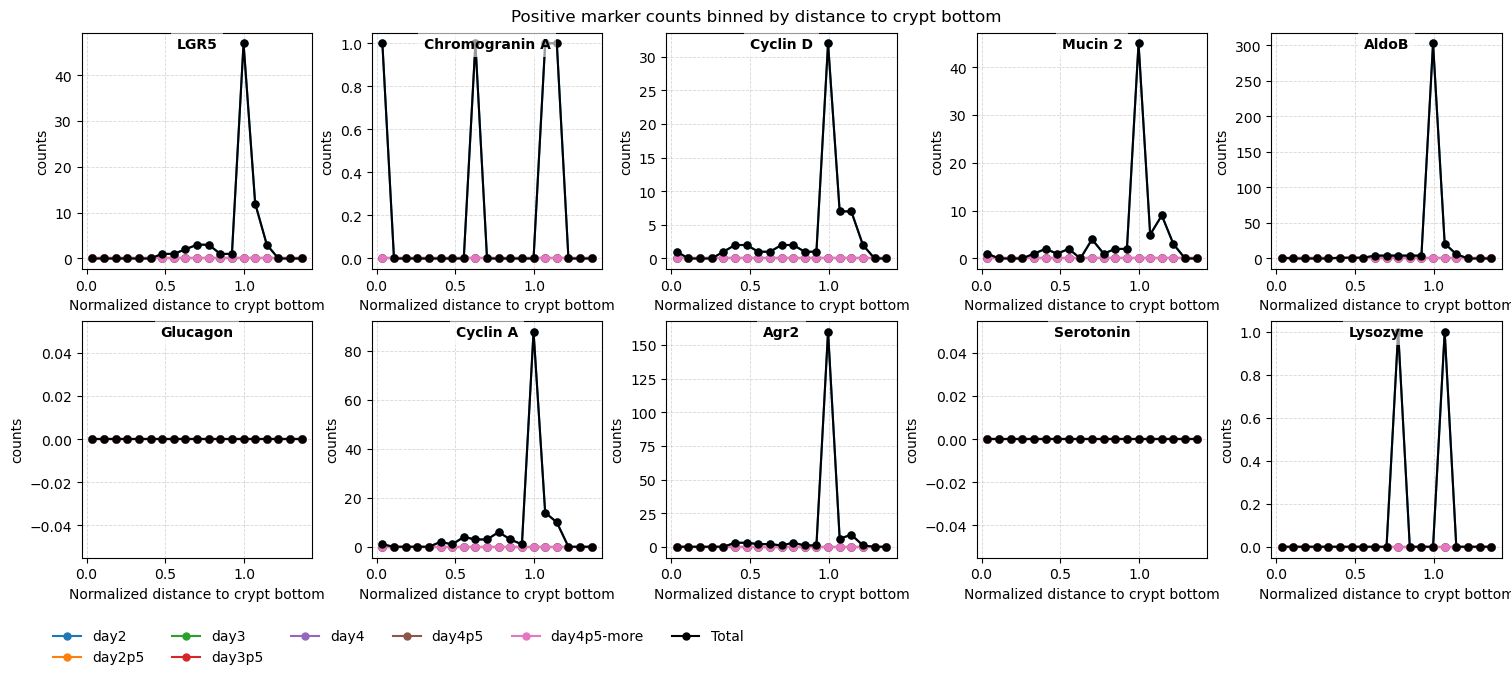

In [115]:
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers, num_pos_per_bin[:,i,:].T, marker='o', linewidth=1.5, markersize=5)
    ax.plot(bin_centers, np.sum(num_pos_per_bin[:,i,:], axis=0), marker='o', linewidth=1.5, markersize=5, color='k', label='Combined')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("counts")

# build legend labels: all timepoints + total
legend_labels = timepoints + ['Total']

# use handles from the first subplot
handles = [axes.flat[0].lines[j] for j in range(len(timepoints) + 1)]

# place legend below all subplots
fig.legend(handles, legend_labels,
           loc='upper right',
           ncol=min(6, len(legend_labels)),
           bbox_to_anchor=(0.5, -0.02),
           frameon=False)


plt.suptitle("Positive marker counts binned by distance to crypt bottom")
plt.show()


/tmp/ipykernel_1181771/3408659643.py:16: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_1181771/3408659643.py:17: RuntimeWarning:

invalid value encountered in divide



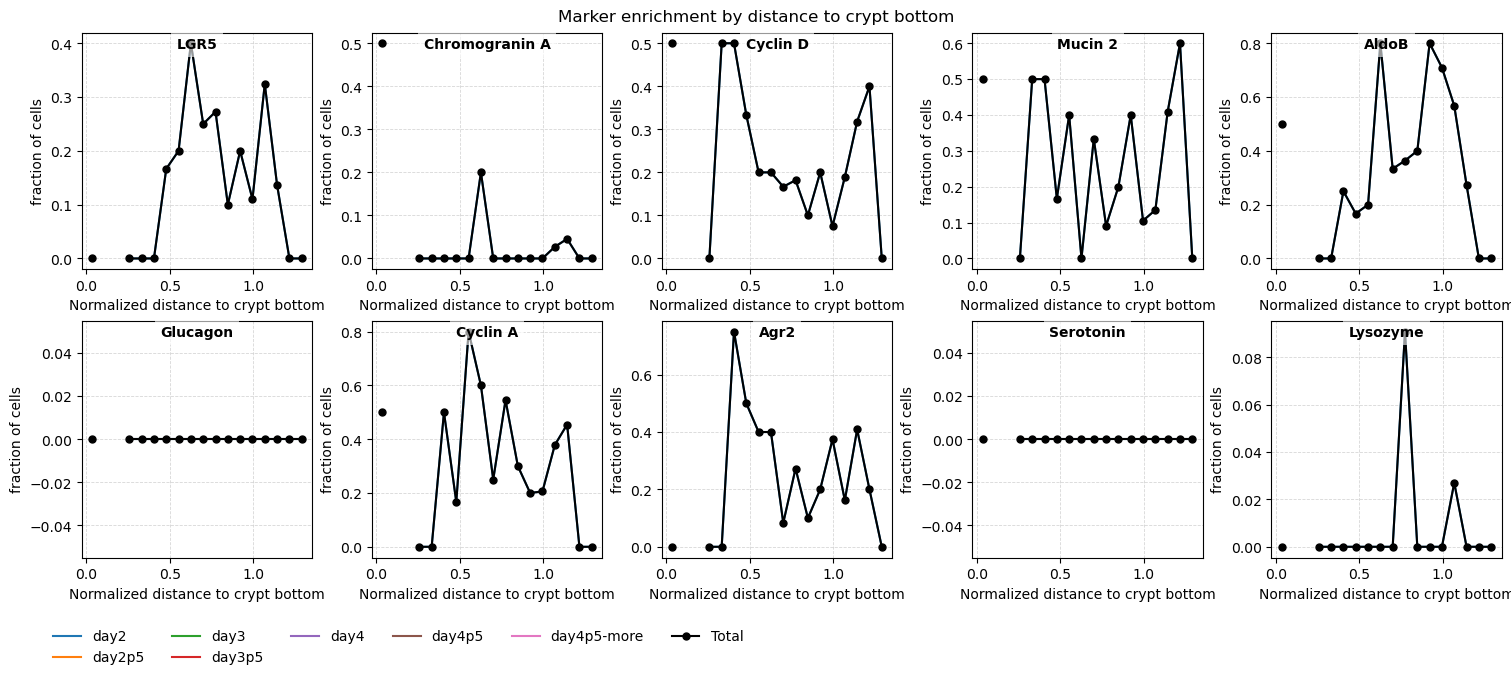

In [116]:
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers, num_pos_per_bin[:,i,:].T/num_cells_per_bin.T, linewidth=1.5, markersize=5)
    ax.plot(bin_centers, np.sum(num_pos_per_bin[:,i,:], axis=0)/np.sum(num_cells_per_bin, axis=0), marker='o', linewidth=1.5, markersize=5, color='k', label='Combined')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("fraction of cells")

# build legend labels: all timepoints + total
legend_labels = timepoints + ['Total']

# use handles from the first subplot
handles = [axes.flat[0].lines[j] for j in range(len(timepoints) + 1)]

# place legend below all subplots
fig.legend(handles, legend_labels,
           loc='upper right',
           ncol=min(6, len(legend_labels)),
           bbox_to_anchor=(0.5, -0.02),
           frameon=False)


plt.suptitle("Marker enrichment by distance to crypt bottom")
plt.show()


NameError: name 'total_frac_mean' is not defined

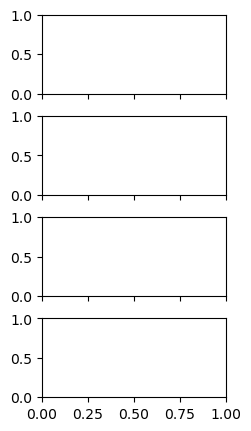

In [117]:
# Markers of interest, in order: rows
target_markers = ["LGR5", "AldoB", "Serotonin", "Lysozyme"]

# Colors matching earlier assignment
marker_colors = {
    "LGR5":      "#1f77b4",  # blue
    "AldoB":     "#2ca02c",  # green
    "Serotonin": "#d62728",  # red
    "Lysozyme":  "#9467bd",  # purple
}

# Get indices of these markers in marker_names
target_indices = [marker_names.index(m) for m in target_markers]

n_rows = len(target_markers)
n_cols = 1

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(2.4, 1.05 * n_rows),
    sharex=True,
    constrained_layout=True
)

# Ensure axes is iterable
axes = np.atleast_1d(axes)

for row, m_idx in enumerate(target_indices):
    ax = axes[row]
    marker_name = marker_names[m_idx]
    color = marker_colors[marker_name]

    # Total fraction from bootstrap
    y_mean  = total_frac_mean[m_idx]      # (n_bins,)
    y_lower = total_frac_lower[m_idx]
    y_upper = total_frac_upper[m_idx]

    # Shaded CI
    ax.fill_between(
        1.25*bin_centers,
        y_lower,
        y_upper,
        color=color,
        alpha=0.25,
        linewidth=0
    )

    # Mean line
    ax.plot(
        1.25*bin_centers,
        y_mean,
        color=color,
        linewidth=2.0
    )

    ax.set_ylabel("fraction of cells")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    # Marker label inside each subplot
    ax.text(
        0.02, 0.98,
        marker_name,
        transform=ax.transAxes,
        ha="left", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
    )

# find global min across all axes
global_min = np.inf
for ax in axes:
    y0, y1 = ax.get_ylim()
    if y0 < global_min:
        global_min = y0

# update only the lower bound for all axes
for ax in axes:
    y0, y1 = ax.get_ylim()
    ax.set_ylim(global_min, y1)

# Shared x-label only on bottom axis
axes[-1].set_xlabel(r"$d$ (crypt length)")

fig.savefig("crypt_analysis.svg", format="svg")


plt.show()


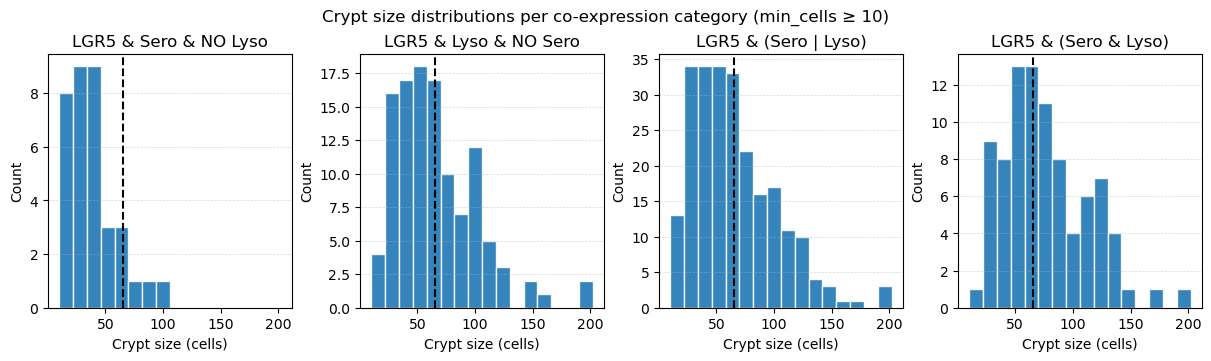

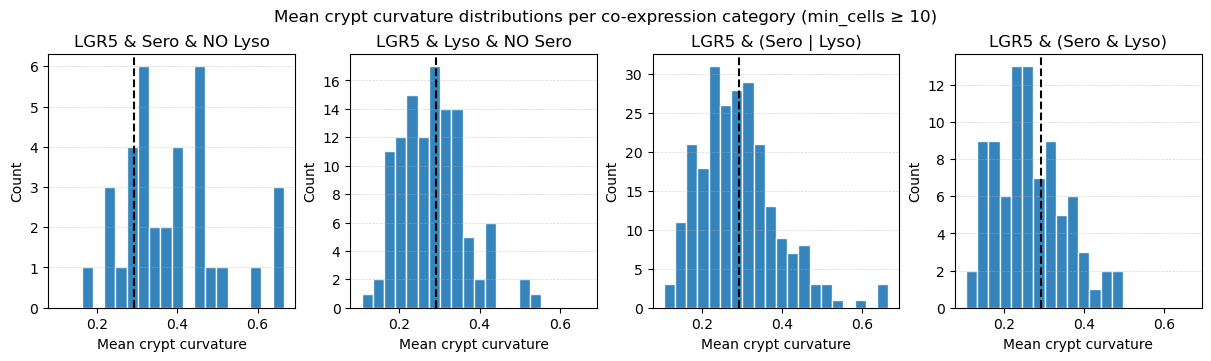

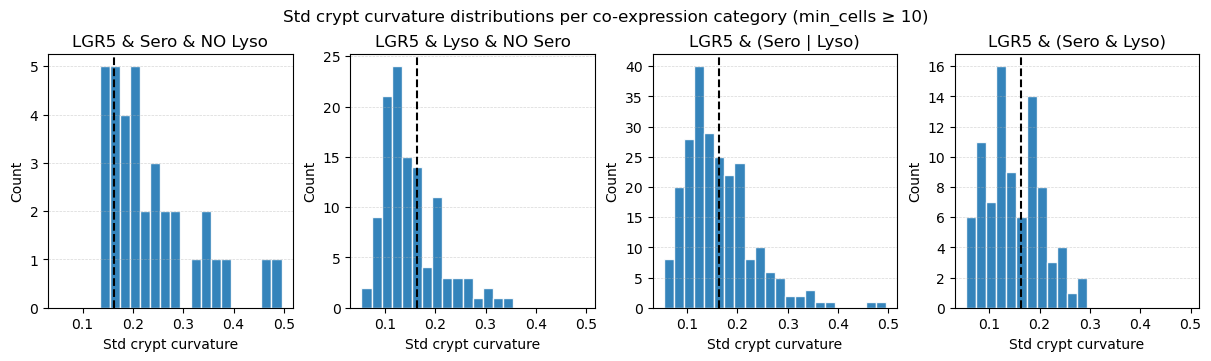

In [ ]:
def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)

# --- Co-expression condition labels (order must match marker_coexpression output) ---
labels_cond = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
]

# --- configuration ---
min_cells = 10      # require at least this many cells in a crypt patch
pos_threshold = 1   # forwarded to marker_coexpression if you wish to change it

# --- Collect crypt sizes per co-expression category ---
size_by_cond = [ [] for _ in range(len(labels_cond)) ]  # 4 categories
mean_curv_by_cond = [ [] for _ in range(len(labels_cond)) ]  # 4 categories
std_curv_by_cond = [ [] for _ in range(len(labels_cond)) ]  # 4 categories


for tp, d in results.items():  # loop over timepoints
    HKS_all      = d.get("HKS_all",  np.array([], dtype=object))
    markers_all  = d.get("markers_all",  np.array([], dtype=object))
    crypts_all   = d.get("crypts_all",   [])
    marker_names = d.get("marker_names", None)

    if markers_all.size == 0:
        continue

    if isinstance(crypts_all, np.ndarray): 
        crypts_all = crypts_all.tolist()

    # indices of the markers used in co-expression
    i_LGR5 = marker_names.index("LGR5")        # raises if not found
    i_Sero = marker_names.index("Serotonin")
    i_Lyso = marker_names.index("Lysozyme")

    n_items = len(markers_all)
    for i in range(n_items):  # loop over organoids
        markers = markers_all[i]         # (n_cells, n_markers)
        if markers is None:
            continue

        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        if not crypt_patches:
            continue

        # filter crypts by minimum size
        crypt_patches = [p for p in crypt_patches if len(p) >= min_cells]

        # --- per-crypt processing ---
        for patch in crypt_patches:
            # crypt size = number of cells in the patch
            crypt_size = int(len(patch))

            # calculate curvature
            idx = np.fromiter(patch, dtype=int)
            curv_crypt = hks_to_curv_proxy_single_t(HKS_all[i][idx, 0], 1.0)

            # co-expression vector (4 categories, 0/1 each; categories may overlap)
            coexp = marker_coexpression(patch, markers, i_LGR5, i_Sero, i_Lyso, pos_threshold=pos_threshold)

            # append this crypt size to each category that is true
            for ci in range(len(labels_cond)):
                if coexp[ci] == 1:
                    size_by_cond[ci].append(crypt_size)
                    mean_curv_by_cond[ci].append(np.mean(curv_crypt))
                    std_curv_by_cond[ci].append(np.std(curv_crypt))


# --- Prepare shared bins across all categories for comparability ---
all_sizes = np.concatenate([np.array(s, dtype=int) for s in size_by_cond if len(s) > 0]) if any(len(s)>0 for s in size_by_cond) else np.array([], dtype=int)
all_curv_mean = np.concatenate([np.array(s) for s in mean_curv_by_cond if len(s) > 0]) if any(len(s)>0 for s in mean_curv_by_cond) else np.array([])
all_curv_std = np.concatenate([np.array(s) for s in std_curv_by_cond if len(s) > 0]) if any(len(s)>0 for s in std_curv_by_cond) else np.array([])



# Choose shared bins (you can switch to e.g. np.arange if you want integer-width bins)
bins = np.histogram_bin_edges(all_sizes, bins='auto')

fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
axes = axes.ravel()

for ci in range(len(labels_cond)):
    ax = axes[ci]

    ax.hist(size_by_cond[ci], bins=bins, edgecolor="white", alpha=0.9)
    ax.set_title(labels_cond[ci])
    ax.set_xlabel("Crypt size (cells)")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.axvline(np.mean(all_sizes), color="k", linestyle="--")


fig.suptitle(f"Crypt size distributions per co-expression category (min_cells ≥ {min_cells})")
plt.show()


# Choose shared bins (you can switch to e.g. np.arange if you want integer-width bins)
bins = np.histogram_bin_edges(all_curv_mean, bins='auto')

fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
axes = axes.ravel()

for ci in range(len(labels_cond)):
    ax = axes[ci]

    ax.hist(mean_curv_by_cond[ci], bins=bins, edgecolor="white", alpha=0.9)
    ax.set_title(labels_cond[ci])
    ax.set_xlabel("Mean crypt curvature")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.axvline(np.mean(all_curv_mean), color="k", linestyle="--")

fig.suptitle(f"Mean crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})")
plt.show()


# Choose shared bins (you can switch to e.g. np.arange if you want integer-width bins)
bins = np.histogram_bin_edges(all_curv_std, bins='auto')

fig, axes = plt.subplots(1, len(labels_cond), figsize=(12, 3.5), constrained_layout=True)
axes = axes.ravel()

for ci in range(len(labels_cond)):
    ax = axes[ci]

    ax.hist(std_curv_by_cond[ci], bins=bins, edgecolor="white", alpha=0.9)
    ax.set_title(labels_cond[ci])
    ax.set_xlabel("Std crypt curvature")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.axvline(np.mean(all_curv_std), color="k", linestyle="--")


fig.suptitle(f"Std crypt curvature distributions per co-expression category (min_cells ≥ {min_cells})")
plt.show()

## Curvature correlations in the crypts

(348, 24, 1, 1)


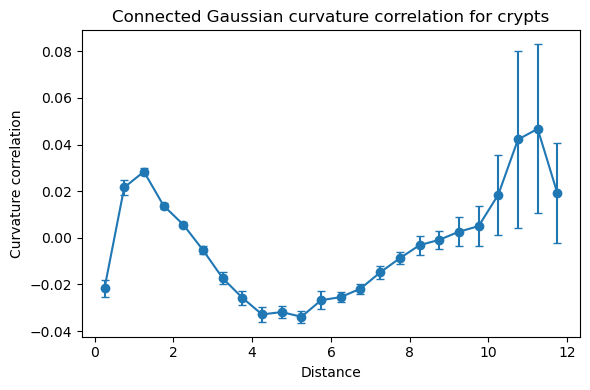

In [ ]:
from src.nonlocal_correlations import *

dmax = 12
nbins = 24
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)


curv_corr_conn = []
num_cells_crypts = []

for tp, d in results.items():
    dist_heat_all= d.get("dist_heat_all",  np.array([], dtype=object))
    HKS_all      = d.get("HKS_all",  np.array([], dtype=object))
    crypts_all   = d.get("crypts_all",   [])

    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_orgs = len(markers_all)
    for i in range(n_orgs):
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)


        if len(crypt_patches) == 0:
            continue

        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)
            
            dist_heat_crypt = dist_heat_all[i][np.ix_(idx, idx)]
            areas_dummy = np.zeros(len(idx))
            curv_crypt = hks_to_curv_proxy_single_t(HKS_all[i][idx, 0], 1.0)

            bins_dist = pair_bins_by_distance(dist_heat_crypt, areas_dummy, bin_edges, use_area_weights=False)
            Corr, Corr_conn, _, _ = compute_two_point_correlations(bins_dist, curv_crypt)
            
            curv_corr_conn.append(Corr_conn)
            num_cells_crypts.append(len(idx))


curv_corr_conn = np.stack(curv_corr_conn)
print(curv_corr_conn.shape)


# Plot the curvature correlations of the crypts
A = curv_corr_conn[:, :, 0, 0]             # shape: (n_reps, n_bins)

means = np.nanmean(A, axis=0)
std   = np.nanstd(A, axis=0, ddof=1)       # sample std (use ddof=0 for population)
n     = np.sum(~np.isnan(A), axis=0)

# avoid meaningless error bars where n < 2
std = np.where(n > 1, std, np.nan)
sem = np.where(n > 1, std / np.sqrt(n), np.nan)

plt.figure(figsize=(6, 4))
plt.errorbar(bin_centers, means, yerr=sem, fmt='o-', capsize=3)
plt.xlabel("Distance")
plt.ylabel("Curvature correlation")
plt.title("Connected Gaussian curvature correlation for crypts")
# plt.legend()
plt.tight_layout()


/tmp/ipykernel_271531/3645180646.py:15: RuntimeWarning:

Mean of empty slice

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning:

Degrees of freedom <= 0 for slice.



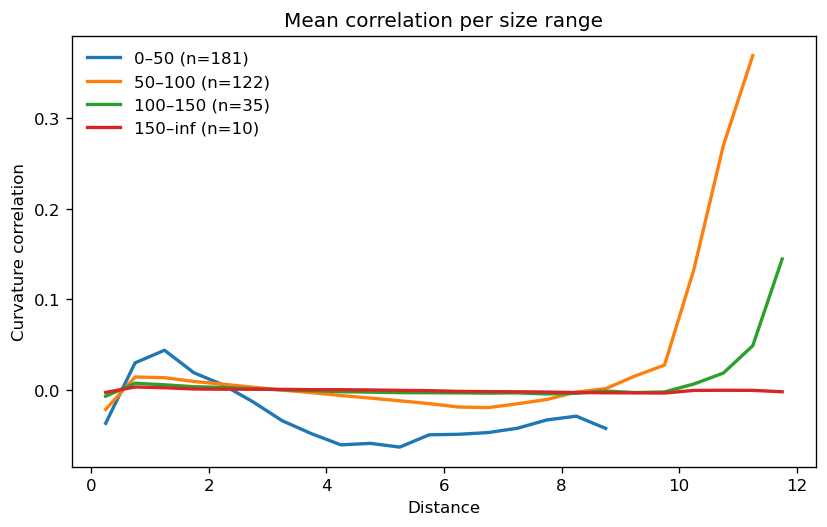

In [ ]:
A = np.asarray(curv_corr_conn[:, :, 0, 0], dtype=float)  # (n_curves, n_bins)
num_cells_crypts = np.asarray(num_cells_crypts)

# Define your size bins (edges are inclusive on the right except the first)
bin_edges = np.array([0, 50, 100, 150, np.inf])  # <-- set your own ranges
bin_ids = np.digitize(num_cells_crypts, bin_edges, right=True)  # 1..len(bin_edges)

plt.figure(figsize=(7, 4.5), dpi=120)

for b in range(1, len(bin_edges)):
    mask = (bin_ids == b)
    n = np.sum(mask)
    if n == 0:
        continue
    mean_curve = np.nanmean(A[mask], axis=0)
    # optional: shaded variability
    std_curve  = np.nanstd(A[mask], axis=0, ddof=1) if n > 1 else np.full(A.shape[1], np.nan)

    lo = bin_edges[b-1]
    hi = bin_edges[b]
    label = f"{lo:g}–{hi:g} (n={n})"

    plt.plot(bin_centers, mean_curve, linewidth=2, label=label)
    # plt.fill_between(bin_centers, mean_curve-std_curve, mean_curve+std_curve, alpha=0.15)

plt.xlabel("Distance")
plt.ylabel("Curvature correlation")
plt.title("Mean correlation per size range")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

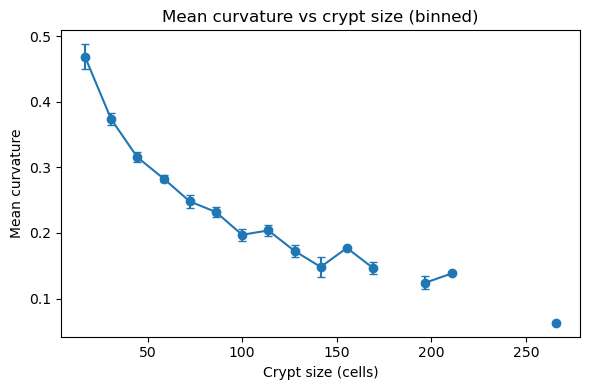

In [ ]:
mean_curv_per_crypt = []
num_cells_crypts = []   # keep as you already do

for tp, d in results.items():
    dist_heat_all = d.get("dist_heat_all", np.array([], dtype=object))
    HKS_all       = d.get("HKS_all",       np.array([], dtype=object))
    crypts_all    = d.get("crypts_all",    [])
    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_orgs = len(HKS_all)  # or whatever list matches your indices here
    for i in range(n_orgs):
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        if not crypt_patches: 
            continue

        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)

            # per-crypt curvature values (one per cell)
            curv_crypt = hks_to_curv_proxy_single_t(HKS_all[i][idx, 0], 1.0)

            # store one number per crypt: its mean curvature (ignore NaNs)
            mean_curv_per_crypt.append(np.nanmean(curv_crypt))
            num_cells_crypts.append(len(idx))

# choose edges you like; here: automatic binning
sizes = np.asarray(num_cells_crypts)
vals  = np.asarray(mean_curv_per_crypt)

edges = np.histogram_bin_edges(sizes, bins='auto')
bin_ids = np.digitize(sizes, edges, right=True)

bin_centers = 0.5*(edges[:-1] + edges[1:])
means = np.full(len(bin_centers), np.nan)
sems  = np.full(len(bin_centers), np.nan)

for b in range(1, len(edges)):
    m = (bin_ids == b)
    v = vals[m]
    n = np.sum(~np.isnan(v))
    if n == 0: 
        continue
    mu = np.nanmean(v)
    sd = np.nanstd(v, ddof=1) if n > 1 else np.nan
    se = sd/np.sqrt(n) if n > 1 else np.nan
    means[b-1] = mu
    sems[b-1]  = se

plt.figure(figsize=(6,4))
plt.errorbar(bin_centers, means, yerr=sems, fmt='o-', capsize=3)
plt.xlabel("Crypt size (cells)")
plt.ylabel("Mean curvature")
plt.title("Mean curvature vs crypt size (binned)")
plt.tight_layout()



## Crypt imbalances (in organoids with 2+ crypts)

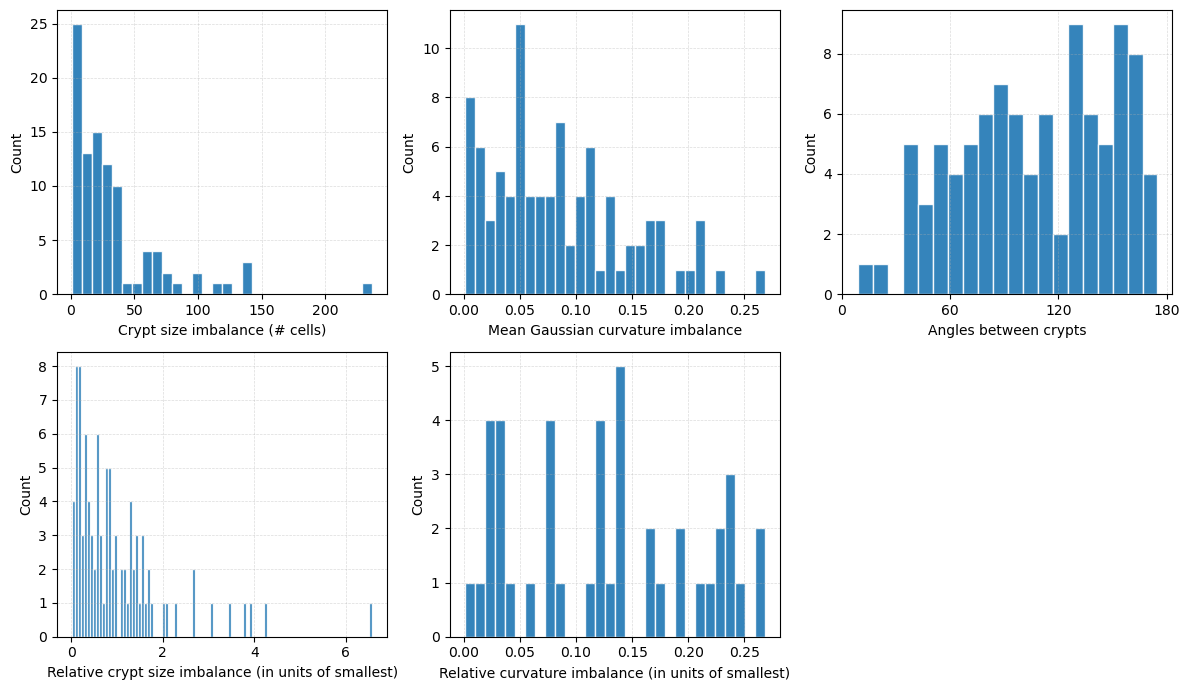

In [ ]:

def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)


size_diff = []
curv_diff = []
size_diff_rel = []
curv_diff_rel = []
angles_deg = []  # NEW: pairwise angles between crypts (in degrees)

for tp, d in results.items():
    HKS_all        = d.get("HKS_all",        np.array([], dtype=object))
    crypts_all     = d.get("crypts_all",     [])
    villus_all     = d.get("villus_all",     [])
    centroids_all  = d.get("centroids_all",  np.array([], dtype=object))

    # normalize potentially object arrays/lists
    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
    if isinstance(villus_all, np.ndarray): villus_all = villus_all.tolist()

    n_orgs = len(HKS_all)
    for i in range(n_orgs):
        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        villus_patches = _to_patch_list(villus_all[i] if i < len(villus_all) else None)
        if not villus_patches:
            continue  # need a villus to define the rays
        villus_patch = villus_patches[0]  # you filtered to exactly one villus earlier

        # only examine organoids with 2 or more crypts
        num_crypts = len(crypt_patches)
        if num_crypts < 2:
            continue

        # --- size/curvature diffs (as before) ---
        crypt_sizes = np.zeros(num_crypts, dtype=float)
        crypt_mean_curv = np.zeros(num_crypts, dtype=float)

        for j, patch in enumerate(crypt_patches):
            idx = np.fromiter(patch, dtype=int)
            curv_crypt = hks_to_curv_proxy_single_t(HKS_all[i][idx, 0], 1.0)
            crypt_sizes[j] = len(idx)
            crypt_mean_curv[j] = np.nanmean(curv_crypt)

        diff = crypt_sizes[:, None] - crypt_sizes[None, :]
        size_diff.append(diff[np.triu_indices(num_crypts, k=1)])
        size_diff_rel.append(diff[np.triu_indices(num_crypts, k=1)]/np.min(crypt_sizes) )


        diff = crypt_mean_curv[:, None] - crypt_mean_curv[None, :]
        curv_diff.append(diff[np.triu_indices(num_crypts, k=1)])
        curv_diff_rel.append(diff[np.triu_indices(num_crypts, k=1)]/np.min(crypt_mean_curv))


        # --- ANGLES: villus→crypt rays ---
        C = centroids_all[i]  # shape (n_cells, 3) or (n_cells, d)
        if C is None:
            continue

        # villus center-of-mass
        v_idx = np.fromiter(villus_patch, dtype=int)
        v_com = np.nanmean(C[v_idx, :], axis=0)

        # crypt centers & rays
        rays = []
        for patch in crypt_patches:
            idx = np.fromiter(patch, dtype=int)
            c_com = np.nanmean(C[idx, :], axis=0)
            ray = c_com - v_com
            rays.append(ray)

        rays = np.asarray(rays, dtype=float)  # (num_crypts, d)
        # normalize norms (avoid zero by masking)
        norms = np.linalg.norm(rays, axis=1)
        valid = norms > 0
        if np.count_nonzero(valid) < 2:
            continue  # cannot form angles

        # pairwise angles via dot product
        # Build full cosine matrix: cos(theta_ij) = (ri·rj) / (||ri||*||rj||)
        R = rays.copy()
        # Safe normalization
        Rn = np.zeros_like(R)
        Rn[valid] = R[valid] / norms[valid, None]

        cosM = np.clip(Rn @ Rn.T, -1.0, 1.0)  # (num_crypts, num_crypts)
        theta = np.degrees(np.arccos(cosM))   # angles in degrees
        # keep strictly upper triangle (i<j)
        angles_deg.append(theta[np.triu_indices(num_crypts, k=1)])



size_diff = np.abs(np.concatenate(size_diff))
curv_diff = np.abs(np.concatenate(curv_diff))
size_diff_rel = np.abs(np.concatenate(size_diff_rel))
curv_diff_rel = np.abs(np.concatenate(curv_diff_rel))

angles_deg = np.concatenate(angles_deg)

plt.figure(figsize=(12, 7))

plt.subplot(2, 3, 1)
plt.hist(size_diff, bins=30, edgecolor="white", alpha=0.9)
plt.xlabel("Crypt size imbalance (# cells)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 2)
lo, hi = np.percentile(curv_diff, [0, 95])
plt.hist(curv_diff, bins=30, range=(lo, hi), edgecolor="white", alpha=0.9)
plt.xlabel("Mean Gaussian curvature imbalance")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 3)
plt.hist(angles_deg, bins=20, edgecolor="white", alpha=0.9)
plt.xticks([0, 60, 120, 180])
plt.xlabel("Angles between crypts")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 4)
plt.hist(size_diff_rel, bins=100, edgecolor="white", alpha=0.9)
plt.xlabel("Relative crypt size imbalance (in units of smallest)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.subplot(2, 3, 5)
lo, hi = np.percentile(curv_diff, [0, 95])
plt.hist(curv_diff_rel, bins=30, range=(lo, hi), edgecolor="white", alpha=0.9)
plt.xlabel("Relative curvature imbalance (in units of smallest)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
plt.tight_layout()

plt.show()


## Cluster crypts according to morphology

In [ ]:
from scipy.stats import skew
from scipy.spatial import ConvexHull

HKS_idx = 3

# Collect rows here
crypt_feature_rows = []

for tp, d in results.items():
    # pull objects (with safe defaults)
    HKS_all       = d.get("HKS_all",       np.array([], dtype=object))
    crypts_all    = d.get("crypts_all",    [])
    centroids_all = d.get("centroids_all", np.array([], dtype=object))
    cell_areas_all= d.get("cell_areas_all", np.array([], dtype=object))  # <-- make sure you stored this
    label_uids    = d.get("label_uid",     np.array([], dtype=object))

    # ensure list-like
    if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()

    n_orgs = len(HKS_all)
    for i in range(n_orgs):
        label_uid   = label_uids[i] if i < len(label_uids) else None

        crypt_patches = _to_patch_list(crypts_all[i] if i < len(crypts_all) else None)
        if len(crypt_patches) == 0:
            continue

        # fetch per-organoid arrays
        HKS_i       = HKS_all[i]
        C_i         = centroids_all[i]
        cell_areas_i= cell_areas_all[i] if i < len(cell_areas_all) else None

        for j, patch in enumerate(crypt_patches):
            idx = np.fromiter(patch, dtype=int)

            # ----- curvature proxy from HKS -----
            curv = hks_to_curv_proxy_single_t(HKS_i[idx, HKS_idx], t_HKS[HKS_idx])

            mean_curv = float(np.mean(curv))
            std_curv  = float(np.std(curv, ddof=0))
            # bias=False gives Fisher’s definition (0 for normal); fallback if <3 values
            skew_curv = float(skew(curv, bias=False)) if curv.size >= 3 else np.nan

            # ----- number of cells -----
            n_cells = int(len(idx))

            # ----- surface area (sum of per-cell areas) -----
            surface_area_crypt = float(np.nansum(np.asarray(cell_areas_i)[idx]))
            
            # ----- enclosed volume (3D convex hull of centroids) -----
            vol_crypt = np.nan
            try:
                pts = np.asarray(C_i)[idx, :]  # (n, 3)
                if pts.shape[0] >= 4 and np.all(np.isfinite(pts)):
                    hull = ConvexHull(pts)
                    vol_crypt = float(hull.volume)
            except Exception:
                # keep vol_crypt as NaN if hull fails (coplanar points, degeneracy, etc.)
                pass

            # assemble row
            crypt_feature_rows.append({
                "timepoint": tp,
                "label_uid": label_uid,
                "organoid_idx": i,
                "crypt_idx": j,                # index within organoid
                "n_cells": n_cells,
                "mean_curv": mean_curv,
                "std_curv": std_curv,
                "skew_curv": skew_curv,
                "surface_area": surface_area_crypt,
                "enclosed_volume": vol_crypt,  # convex-hull volume
            })

# Final DataFrame of features (one row per crypt)
crypt_features_df = pd.DataFrame(crypt_feature_rows)

# Example: drop rows missing volume or surface area if you want a clean table
# crypt_features_df = crypt_features_df.dropna(subset=["surface_area", "enclosed_volume"]).reset_index(drop=True)

print(f"Built feature table with {len(crypt_features_df)} crypts")
display(crypt_features_df.head())


Built feature table with 348 crypts


,timepoint,label_uid,organoid_idx,crypt_idx,n_cells,mean_curv,std_curv,skew_curv,surface_area,enclosed_volume
0,day3p5,day3p5_A02_30,5,0,29,0.410763,0.141717,-0.123746,27.224032,12.456330
1,day3p5,day3p5_A02_32,7,0,31,0.398057,0.136756,-0.009773,26.785487,12.891346
2,day3p5,day3p5_A02_32,7,1,41,0.336658,0.115215,-0.253098,33.138983,18.960394
3,day3p5,day3p5_A02_32,7,2,10,0.335254,0.083373,-0.090588,14.625655,2.585673
4,day3p5,day3p5_A02_60,25,0,11,0.289939,0.047263,0.226629,9.630827,1.505129


Clustering done with k=4, silhouette=0.387
Total crypts clustered: 348


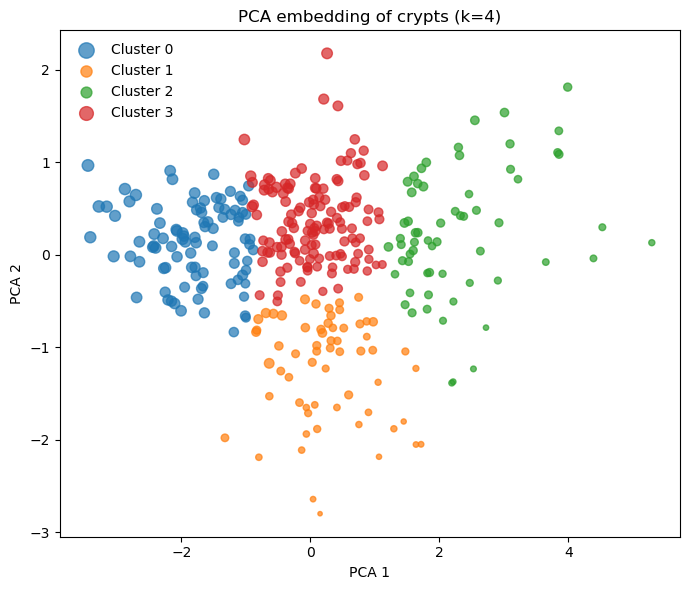


Per-cluster median summary (interpretable units):


,n_cells,surface_area,enclosed_volume,sphericity,cell_density,mean_curv,std_curv,skew_curv
cluster,,,,,,,,
0,99.0,77.958182,79.647675,1.138781,1.266105,0.172870,0.076509,-0.079056
1,23.5,25.246701,11.366583,0.943872,2.265021,0.282825,0.087842,0.068987
2,26.0,28.957088,12.715166,0.907132,2.079127,0.440119,0.152398,-0.104263
3,53.0,47.634550,33.402038,1.059586,1.613514,0.285429,0.119420,-0.020090


In [ ]:
# === Crypt Morphology Clustering ===
# Inputs: crypt_features_df with (at least) these columns per crypt:
#   ["timepoint", "label_uid", "organoid_idx", "crypt_idx",
#    "n_cells", "mean_curv", "std_curv", "skew_curv", "surface_area", "enclosed_volume"]
#
# Output artifacts:
#   clustered_df: original rows + engineered features + "cluster" + "cluster_name" + PCA coords
#   models: dict with scaler, pca, kmeans, feature_names used
#   plots: 2x figures for quick interpretation

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer



# ------------------------------------------
# Feature engineering (shape descriptors)
# ------------------------------------------

df = crypt_features_df.copy()

# Guard against nonpositive area/volume for logs
area = df["surface_area"].astype(float).clip(lower=np.finfo(float).eps)
vol  = df["enclosed_volume"].astype(float).clip(lower=np.finfo(float).eps)
n    = df["n_cells"].astype(float).clip(lower=np.finfo(float).eps)

# Sphericity (dimensionless; 1 = perfect sphere):
# ψ = π^(1/3) * (6V)^(2/3) / A
sphericity = (np.pi**(1/3)) * (6.0*vol)**(2.0/3.0) / area
df["sphericity"] = sphericity.replace([np.inf, -np.inf], np.nan)

# Cell density (cells per volume)
df["cell_density"] = n / vol

# Log-scaled size features for better numeric behavior
df["log_area"] = np.log1p(area)       # log(1 + A)
df["log_vol"]  = np.log1p(vol)        # log(1 + V)
df["log_n"]    = np.log1p(n)          # log(1 + N)

# List of features to cluster on (mix of size + shape + curvature stats)
# feature_cols = [
#     "log_vol", "log_area", "log_n",     # size-ish (log-stabilized)
# #    "sphericity",        # shape/intensity
#     "mean_curv", "std_curv", "skew_curv" # curvature summaries
# ]

feature_cols = [
     "log_n",     
    "mean_curv", "std_curv" # curvature summaries
]

# ------------------------------------------
# Clean, impute, scale, and reduce
# ------------------------------------------
X_raw = df[feature_cols].astype(float).values

# Impute missing values with median (robust)
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X_raw)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Dimensionality reduction for visualization + denoising
# Keep enough components to explain ~95% variance (cap at 6 for stability)
pca = PCA(n_components=min(6, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

X_2d = X_pca[:, :2]
embed_name = "PCA"

# ------------------------------------------
# Choose k (4–5 by default) via silhouette
# ------------------------------------------
candidate_k = [4,5,6,7,8]   # You can broaden to [3,4,5,6] if you like
best_k = None
best_model = None
best_score = -np.inf

for k in candidate_k:
    model = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = model.fit_predict(X_pca)  # cluster in PCA space for stability
    # Ensure silhouette is defined (>=2 labels)
    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_pca, labels)
    else:
        score = -np.inf
    if score > best_score:
        best_score = score
        best_k = k
        best_model = model

kmeans = best_model
labels = kmeans.labels_

# ------------------------------------------
# Pack results and human-friendly names
# ------------------------------------------
cluster_map = {c: f"Cluster {c}" for c in range(best_k)}  # simple defaults

clustered_df = df.copy()
clustered_df["cluster"] = labels
clustered_df["cluster_name"] = clustered_df["cluster"].map(cluster_map)

# Add 2D embedding and top 2 PCs for plotting
clustered_df[f"{embed_name}_1"] = X_2d[:, 0]
clustered_df[f"{embed_name}_2"] = X_2d[:, 1]
clustered_df["PC1"] = X_pca[:, 0]
clustered_df["PC2"] = X_pca[:, 1]

# Keep model objects if you want to reuse/transform new data later
models = {
    "imputer": imputer,
    "scaler": scaler,
    "pca": pca,
    "kmeans": kmeans,
    "feature_cols": feature_cols,
    "embed": embed_name
}

print(f"Clustering done with k={best_k}, silhouette={best_score:.3f}")
print(f"Total crypts clustered: {len(clustered_df)}")

# ------------------------------------------
# Quick interpretability visuals
# ------------------------------------------

# (A) 2D embedding colored by cluster (size ~ volume)
plt.figure(figsize=(7,6))
for c in sorted(clustered_df["cluster"].unique()):
    m = clustered_df["cluster"] == c
    plt.scatter(
        clustered_df.loc[m, f"{embed_name}_1"],
        clustered_df.loc[m, f"{embed_name}_2"],
        s=10 + 60*(clustered_df.loc[m, "log_vol"] - clustered_df["log_vol"].min())/
               (clustered_df["log_vol"].max() - clustered_df["log_vol"].min() + 1e-9),
        alpha=0.7,
        label=f"Cluster {c}"
    )
plt.xlabel(f"{embed_name} 1")
plt.ylabel(f"{embed_name} 2")
plt.title(f"{embed_name} embedding of crypts (k={best_k})")
plt.legend(frameon=False, markerscale=1.5)
plt.tight_layout()
plt.show()

# (B) Per-cluster medians of interpretable features
interpretable_cols = ["n_cells","surface_area","enclosed_volume","sphericity","cell_density",
                      "mean_curv","std_curv","skew_curv"]
summary = (
    clustered_df
    .groupby("cluster")[interpretable_cols]
    .median()
    .sort_index()
)

print("\nPer-cluster median summary (interpretable units):")
display(summary)


In [ ]:

# Optional: give human-friendly names by heuristics (round vs long, etc.)
# You can refine these thresholds to your dataset.
def name_clusters_by_heurstics(clustered_df, summary_df, *, lower_q=0.25, upper_q=0.75):
    """
    Build cluster names feature-by-feature from cluster-level medians in summary_df.
    Parts (in order):
      - size: 'small' / 'large' via n_cells (or use 'enclosed_volume'—see note)
      - shape: 'spherical' / 'non-spherical' via sphericity
      - mean curvature: 'flat' / 'curved' via abs(mean_curv)
      - curvature variability: 'regular curvature' / 'irregular curvature' via std_curv

    If a cluster falls between lower_q and upper_q for a given feature, no term is added for that feature.

    Parameters
    ----------
    clustered_df : DataFrame (unused here but kept for signature compatibility)
    summary_df   : DataFrame with one row per cluster and columns:
                   ['n_cells','sphericity','mean_curv','std_curv', ...]
    lower_q      : float, lower quantile threshold (default 0.25)
    upper_q      : float, upper quantile threshold (default 0.75)
    """
    # --- thresholds from cluster medians (summary_df) ---
    # Size: using n_cells median per cluster. If you prefer geometric size, switch to 'enclosed_volume'.
    size_vals = summary_df['n_cells'].astype(float)
    size_lo = size_vals.quantile(lower_q)
    size_hi = size_vals.quantile(upper_q)

    sph_vals = summary_df['sphericity'].astype(float)
    sph_lo = sph_vals.quantile(lower_q)
    sph_hi = sph_vals.quantile(upper_q)

    # Use magnitude of mean curvature for flat/curved
    mean_abs_vals = summary_df['mean_curv'].astype(float).abs()
    mean_abs_lo = mean_abs_vals.quantile(lower_q)
    mean_abs_hi = mean_abs_vals.quantile(upper_q)

    std_vals = summary_df['std_curv'].astype(float)
    std_lo = std_vals.quantile(lower_q)
    std_hi = std_vals.quantile(upper_q)

    names = {}

    for c, row in summary_df.iterrows():
        parts = []

        # --- size (n_cells) ---
        size = float(row['n_cells'])
        if size <= size_lo:
            parts.append("small")
        elif size >= size_hi:
            parts.append("large")

        # --- sphericity ---
        sph = float(row['sphericity'])
        if sph <= sph_lo:
            parts.append("non-spherical")
        elif sph >= sph_hi:
            parts.append("spherical")

        # --- mean curvature magnitude ---
        mean_abs = abs(float(row['mean_curv']))
        if mean_abs <= mean_abs_lo:
            parts.append("flat")
        elif mean_abs >= mean_abs_hi:
            parts.append("curved")

        # --- curvature variability (std) ---
        stdc = float(row['std_curv'])
        if stdc <= std_lo:
            parts.append("regular curvature")
        elif stdc >= std_hi:
            parts.append("irregular curvature")

        # Fallback if no parts were added
        if not parts:
            parts = ["typical"]

        names[c] = " · ".join(parts)

    return names


heur_names = name_clusters_by_heurstics(clustered_df, summary)
clustered_df["cluster_name"] = clustered_df["cluster"].map(heur_names)

print("\nAssigned cluster_name via simple shape heuristics:")
print(clustered_df[["cluster","cluster_name"]].drop_duplicates().sort_values("cluster"))





Assigned cluster_name via simple shape heuristics:
    cluster                                  cluster_name
17        0  large · spherical · flat · regular curvature
3         1                                         small
0         2  non-spherical · curved · irregular curvature
2         3                                       typical


In [ ]:
# === Plot a few random crypts per cluster (no typing module) ===
# Requirements:
# - clustered_df from the clustering step (must contain: crypt_uid, timepoint, label_uid, organoid_idx, crypt_idx, cluster, cluster_name)
# - results dict as you built in your loader (with "centroids_all", "cell_graphs_all", "crypts_all", "HKS_all")
# - your plot_organoid_graph(...) function (already defined by you)
# - helper hks_to_curv_proxy_single_t(HKS_col, t) available in scope
# - _to_patch_list available (as in your code)

import numpy as np
import pandas as pd
import networkx as nx
import plotly.graph_objects as go

# ----------------------------
# Config
# ----------------------------
SAMPLES_PER_CLUSTER = 3
RANDOM_STATE = None
HKS_T_SCALE_INDEX = 0  # which HKS column to use for your curvature proxy (you used 0 before)
HKS_T_VAL = 1.0        # your curvature proxy time parameter (you used 1.0)

rng = np.random.default_rng(RANDOM_STATE)

# ----------------------------
# Helpers
# ----------------------------
def _crypt_uid_key(row):
    """Return a tuple key (timepoint, label_uid, organoid_idx, crypt_idx)."""
    return (str(row["timepoint"]), str(row["label_uid"]), int(row["organoid_idx"]), int(row["crypt_idx"]))

def _sample_per_cluster(df, n_per_cluster, rng):
    out = []
    for _, g in df.groupby("cluster", sort=True):
        k = min(n_per_cluster, len(g))
        out.append(g.sample(n=k, random_state=int(rng.integers(0, 10_000))))
    return pd.concat(out, axis=0).reset_index(drop=True)

def _extract_crypt_components(tp, org_idx, crypt_idx_within_org, d_tp):
    """
    Build (centroids_crypt, G_crypt_reindexed, curv_crypt) for the requested crypt.
    - centroids_crypt: (M, 3)
    - G_crypt_reindexed: networkx.Graph over nodes 0..M-1
    - curv_crypt: (M,) curvature proxy values, aligned with centroids_crypt rows
    """
    # Fetch arrays for this organoid
    centroids_all = d_tp["centroids_all"][org_idx]
    G_full        = d_tp["cell_graphs_all"][org_idx]
    HKS_all       = d_tp["HKS_all"][org_idx]  # shape: (N_cells, n_fields)
    crypts_all    = d_tp["crypts_all"][org_idx]
    crypt_patches = _to_patch_list(crypts_all)

    patch = crypt_patches[crypt_idx_within_org]
    idx = np.fromiter(patch, dtype=int)

    # Subset centroids
    C_sub = np.asarray(centroids_all)[idx, :]  # (M, 3)

    # Subgraph and reindex nodes to 0..M-1 to match C_sub rows
    mapping = {old: new for new, old in enumerate(idx.tolist())}
    G_sub = nx.relabel_nodes(G_full.subgraph(idx), mapping, copy=True)

    # Curvature proxy from HKS
    curv_sub = hks_to_curv_proxy_single_t(HKS_all[idx, HKS_T_SCALE_INDEX], HKS_T_VAL)

    return C_sub, G_sub, np.asarray(curv_sub)

# ----------------------------
# Select examples and plot
# ----------------------------
if "cluster" not in clustered_df.columns:
    raise ValueError("clustered_df must contain a 'cluster' column. Run the clustering step first.")

picked = _sample_per_cluster(clustered_df, SAMPLES_PER_CLUSTER, rng)

# Keep a log so you can find these exact examples elsewhere
preview_records = []

for r in picked.itertuples(index=False):
    tp, label_uid, org_i, crypt_j = r.timepoint, r.label_uid, int(r.organoid_idx), int(r.crypt_idx)
    cl, cl_name = int(r.cluster), str(r.cluster_name)

    d_tp = results[tp]  # this timepoint's store

    try:
        C, Gc, curv = _extract_crypt_components(tp, org_i, crypt_j, d_tp)

        fig = plot_organoid_graph(
            centroids=C,
            graph=Gc,
            node_values=curv,         # color nodes by curvature proxy
            node_size=5,
            edge_width=1.0,
            colorscale="RdBu_r",
            center_at_zero=True,
            loops=None
        )
        fig.update_layout(title_text=f"{tp} | {label_uid} | org {org_i} | crypt {crypt_j} | {cl_name} (cluster {cl})")
        fig.show()

        preview_records.append({
            "cluster": cl,
            "cluster_name": cl_name,
            "timepoint": tp,
            "label_uid": label_uid,
            "organoid_idx": org_i,
            "crypt_idx": crypt_j,
            "n_nodes_plotted": C.shape[0],
        })

    except Exception as e:
        print(f"Failed to plot {tp} / {label_uid} / org {org_i} / crypt {crypt_j}: {e}")

preview_df = pd.DataFrame(preview_records).sort_values(["cluster","timepoint","label_uid","organoid_idx","crypt_idx"])
print("Plotted examples (you can save this for reference):")
display(preview_df)
# Optionally save:
# preview_df.to_csv("cluster_plot_samples.csv", index=False)


Plotted examples (you can save this for reference):


,cluster,cluster_name,timepoint,label_uid,organoid_idx,crypt_idx,n_nodes_plotted
2,0,large · spherical · flat · regular curvature,day4,day4_A04_82,356,1,83
1,0,large · spherical · flat · regular curvature,day4p5,day4p5_B06_77,105,0,91
0,0,large · spherical · flat · regular curvature,day4p5-more,day4p5-more_C05_139,279,0,48
5,1,small,day4,day4_A06_29,92,0,23
4,1,small,day4p5,day4p5_A06_69,34,1,13
3,1,small,day4p5-more,day4p5-more_C03_37,142,0,25
7,2,non-spherical · curved · irregular curvature,day4,day4_A04_61,342,0,16
8,2,non-spherical · curved · irregular curvature,day4,day4_B01_38,171,0,19
6,2,non-spherical · curved · irregular curvature,day4p5-more,day4p5-more_C06_115,348,0,31
11,3,typical,day3p5,day3p5_A02_32,7,1,41


In [ ]:

# --- Prepare cluster indexing ---
clusters_sorted = sorted(clustered_df['cluster'].unique())
cluster_to_row = {c: k for k, c in enumerate(clusters_sorted)}
n_clusters = len(clusters_sorted)

# Config
bin_edges = np.linspace(0.0, 1.4, 20)      # normalized distance bins (0..1)
bin_centers = 0.5 * (np.asarray(bin_edges[:-1]) + np.asarray(bin_edges[1:]))

# Accumulate numerators/denominators per bin across crypts to get a robust curve
M = len(marker_names)
num_pos_per_bin_cluster = np.zeros((n_clusters, M, len(bin_centers)))  # shape (M, nbins)
num_cells_per_bin_cluster = np.zeros((n_clusters, len(bin_centers)))     # shape (nbins,)

# --- Iterate crypts grouped by cluster ---
for c_label, dfc in clustered_df.groupby('cluster'):
    k = cluster_to_row[c_label]  # row index for this cluster

    # iterate each crypt row assigned to this cluster
    for r in dfc.itertuples(index=False):
        tp = r.timepoint
        org_i = int(r.organoid_idx)
        crypt_j = int(r.crypt_idx)

        d = results[tp]

        HKS_all       = d.get("HKS_all",       np.array([], dtype=object))
        crypts_all    = d.get("crypts_all",    [])
        necks_all     = d.get("necks_all",     None)  # optional
        markers_all   = d.get("markers_all",   np.array([], dtype=object))
        geodesic_all  = d.get("dist_heat_all",  np.array([], dtype=object))  # (N,N) per organoid
        Gs            = d.get("cell_graphs_all", [])

        if isinstance(crypts_all, np.ndarray): crypts_all = crypts_all.tolist()
        if isinstance(necks_all, np.ndarray): necks_all = necks_all.tolist()

        HKS = HKS_all[org_i]
        markers = markers_all[org_i]
        geo = geodesic_all[org_i]
        G = Gs[org_i]
        crypt_patches = _to_patch_list(crypts_all[org_i])
        neck_patches = _to_patch_list(necks_all[org_i])

        if not crypt_patches:
            continue

        # process each crypt separately and aggregate
        for crypt in crypt_patches:

            # 1) bottom of crypt
            bottom = _crypt_bottom_index(HKS, t_HKS, crypt)

            # 2) neck ring for this crypt
            neck_nodes = _neck_nodes_for_crypt(G, crypt, neck_patches)
            if len(neck_nodes) == 0: continue

            # 3) normalized distance (bottom -> neck is 1)
            dist_norm = _normalized_distance_to_bottom(geo, bottom, neck_nodes)

            # 4) bin marker positivity across normalized distance
            counts_pos, counts_total = _bin_marker_positivity(markers, dist_norm, bin_edges)

            # accumulate weighted by counts
            num_pos_per_bin_cluster[k] += counts_pos
            num_cells_per_bin_cluster[k] += counts_total


/tmp/ipykernel_271531/1813352721.py:59: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_271531/1813352721.py:59: RuntimeWarning:

invalid value encountered in divide



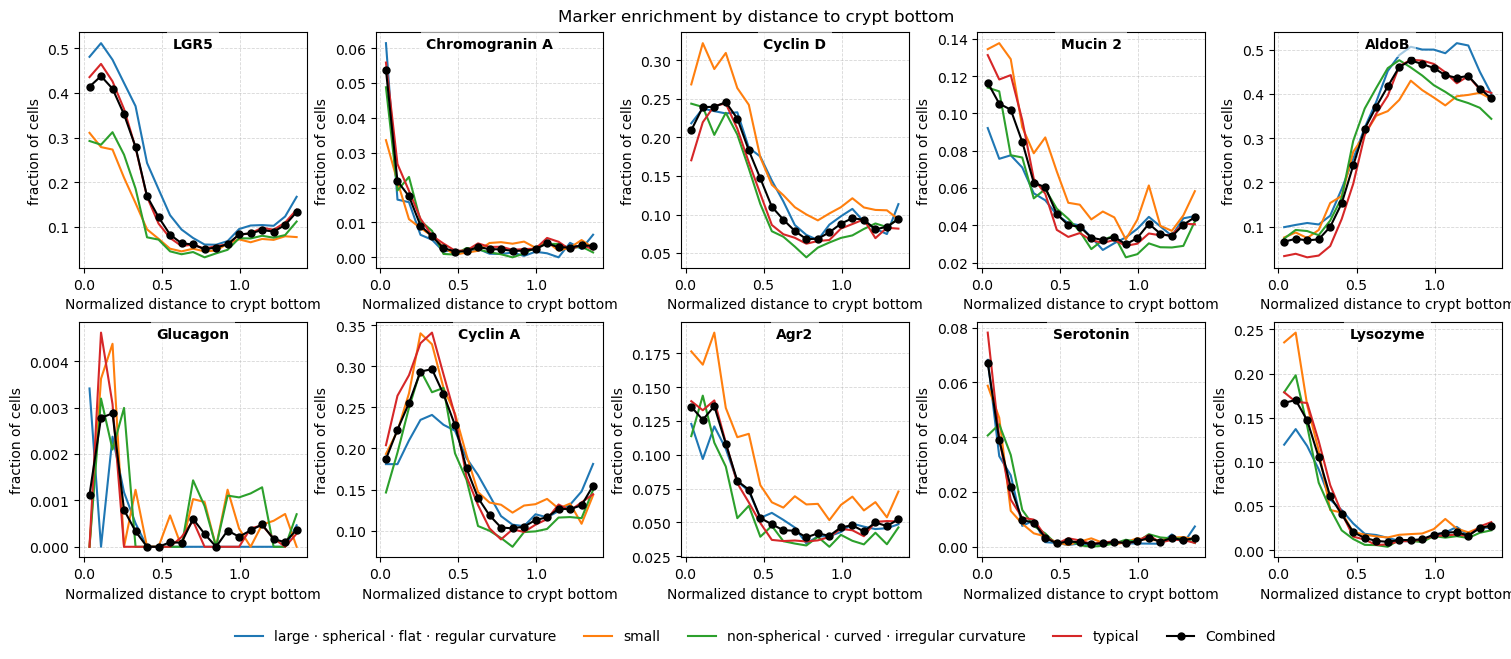

In [ ]:
M = len(marker_names)
n_cols = 5
n_rows = int(np.ceil(M / n_cols))

fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )

for i in range(M):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]

    ax.plot(bin_centers, num_pos_per_bin_cluster[:,i,:].T/num_cells_per_bin_cluster.T, linewidth=1.5, markersize=5)
    ax.plot(bin_centers, np.sum(num_pos_per_bin_cluster[:,i,:], axis=0)/np.sum(num_cells_per_bin_cluster, axis=0), marker='o', linewidth=1.5, markersize=5, color='k', label='Combined')

    ax.text(
        0.5, 0.98,                       # near the top-center of the axes
        marker_names[i],
        transform=ax.transAxes,
        ha="center", va="top",
        fontweight="bold", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)  # optional halo for readability
    )
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Normalized distance to crypt bottom")
    ax.set_ylabel("fraction of cells")


if 'cluster_name' in clustered_df.columns:
    name_map = (
        clustered_df[['cluster','cluster_name']]
        .drop_duplicates()
        .set_index('cluster')['cluster_name']
        .to_dict()
    )
    cluster_labels = [name_map.get(c, f"Cluster {c}") for c in clusters_sorted]
else:
    cluster_labels = [f"Cluster {c}" for c in clusters_sorted]

legend_labels = cluster_labels + ['Combined']

# Handles from the first subplot:
first_ax = axes.flat[0]
# First n_clusters lines are the cluster curves; the last is the black Combined line
handles = [first_ax.lines[j] for j in range(len(clusters_sorted) + 1)]

# Place legend below or wherever you like
fig.legend(
    handles, legend_labels,
    loc='upper center',  # or 'upper right'
    ncol=min(6, len(legend_labels)),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False
)


plt.suptitle("Marker enrichment by distance to crypt bottom")
plt.show()


In [ ]:
# --- Prepare cluster indexing ---
clusters_sorted = sorted(clustered_df['cluster'].unique())
cluster_to_row = {c: k for k, c in enumerate(clusters_sorted)}
n_clusters = len(clusters_sorted)

# --- configuration ---
min_cells = 10       # minimum cells per crypt patch
min_positive = 1     # a marker counts as "present in patch" if >= this many positive cells

M = len(marker_names)  # assuming you already have marker_names in scope

# --- Accumulators over CLUSTERS (crypts only) ---
num_crypts_cluster           = np.zeros(n_clusters, dtype=np.int64)
marker_pos_crypt_cluster     = np.zeros((n_clusters, M), dtype=np.int64)   # patch-wise presence counts
num_pos_cells_crypt_cluster  = np.zeros((n_clusters, M), dtype=np.int64)   # total positive cells per marker
num_cells_crypt_cluster      = np.zeros(n_clusters, dtype=np.int64)        # total cells (denominator)
coexpression_crypt_cluster   = np.zeros((n_clusters, 4))                   # your 4 coexpression categories

# --- Iterate crypts grouped by cluster ---
for c_label, dfc in clustered_df.groupby('cluster'):
    k = cluster_to_row[c_label]  # row index for this cluster

    # iterate each crypt row assigned to this cluster
    for r in dfc.itertuples(index=False):
        tp      = r.timepoint
        org_i   = int(r.organoid_idx)
        crypt_j = int(r.crypt_idx)  # not used explicitly (following your example style)

        d = results[tp]
        markers_all = d.get("markers_all",  np.array([], dtype=object))
        crypts_all  = d.get("crypts_all",   [])
        marker_names_tp = d.get("marker_names", marker_names)  # fall back to global if needed

        if isinstance(crypts_all, np.ndarray): 
            crypts_all = crypts_all.tolist()

        markers = markers_all[org_i]  # (n_cells, n_markers)
        crypt_patches = _to_patch_list(crypts_all[org_i])

        if not crypt_patches:
            continue

        # marker indices (assumed present)
        i_LGR5 = marker_names_tp.index("LGR5")
        i_Sero = marker_names_tp.index("Serotonin")
        i_Lyso = marker_names_tp.index("Lysozyme")

        # (OPTIONAL) filter out crypts with too few cells
        crypt_patches = [p for p in crypt_patches if len(p) >= min_cells]

        # --- CRYPTS (patch-wise + cell-wise) ---
        for patch in crypt_patches:
            num_pos_cells, num_cells = get_marker_counts_per_patch(patch, markers)

            # cell- and patch-wise tallies
            num_cells_crypt_cluster[k]             += num_cells
            num_pos_cells_crypt_cluster[k, :]      += num_pos_cells
            marker_pos_crypt_cluster[k, :]         += (num_pos_cells >= min_positive)
            num_crypts_cluster[k]                  += 1

            # coexpression (your 4-category vector)
            coexpression_crypt_cluster[k, :]       += marker_coexpression(
                patch, markers, i_LGR5, i_Sero, i_Lyso
            )



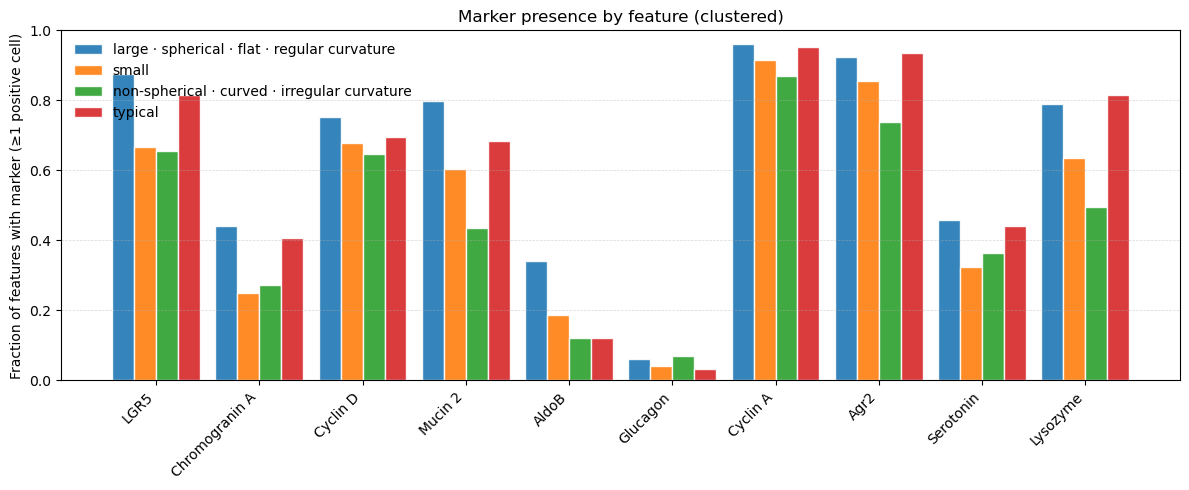

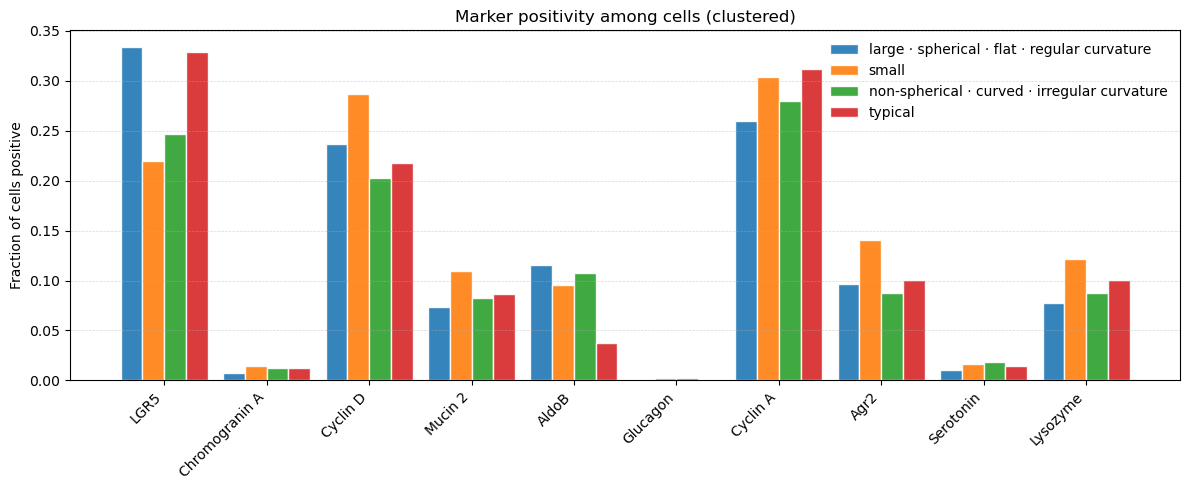

In [ ]:

# --- Build legend labels for clusters ---
if 'cluster_name' in clustered_df.columns:
    name_map = (
        clustered_df[['cluster','cluster_name']]
        .drop_duplicates()
        .set_index('cluster')['cluster_name']
        .to_dict()
    )
    cluster_labels = [name_map.get(c, f"Cluster {c}") for c in clusters_sorted]
else:
    cluster_labels = [f"Cluster {c}" for c in clusters_sorted]

K = len(clusters_sorted)
M = len(marker_names)

# X positions per marker
x = np.arange(M)
# bar width so that K bars fit nicely within ~0.8 of a unit
group_width = 0.85
w = group_width / max(1, K)
# center the K bars around each integer x
offsets = (np.arange(K) - (K-1)/2) * w

# ---------------------------
# Figure 1: Fraction of features (crypt patches) with marker
#   = marker_pos_crypt_cluster[k, m] / num_crypts_cluster[k]
# ---------------------------
plt.figure(figsize=(max(12, 0.8*M), 5))

for ki in range(K):
    denom = num_crypts_cluster[ki]
    vals = np.divide(
        marker_pos_crypt_cluster[ki, :],
        denom,
        out=np.zeros(M, dtype=float),
        where=(denom > 0)
    )
    plt.bar(x + offsets[ki], vals, width=w, label=cluster_labels[ki], edgecolor="white", alpha=0.9)

plt.xticks(x, marker_names, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel(f"Fraction of features with marker (≥{min_positive} positive cell)")
plt.title("Marker presence by feature (clustered)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False,loc='best')
plt.tight_layout()
plt.show()

# ---------------------------
# Figure 2: Fraction of cells positive per marker
#   = num_pos_cells_crypt_cluster[k, m] / num_cells_crypt_cluster[k]
# ---------------------------
plt.figure(figsize=(max(12, 0.8*M), 5))

for ki in range(K):
    denom = num_cells_crypt_cluster[ki]
    vals = np.divide(
        num_pos_cells_crypt_cluster[ki, :],
        denom,
        out=np.zeros(M, dtype=float),
        where=(denom > 0)
    )
    plt.bar(x + offsets[ki], vals, width=w, label=cluster_labels[ki], edgecolor="white", alpha=0.9)

plt.xticks(x, marker_names, rotation=45, ha="right")
# plt.ylim(0, 1)
plt.ylabel("Fraction of cells positive")
plt.title("Marker positivity among cells (clustered)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


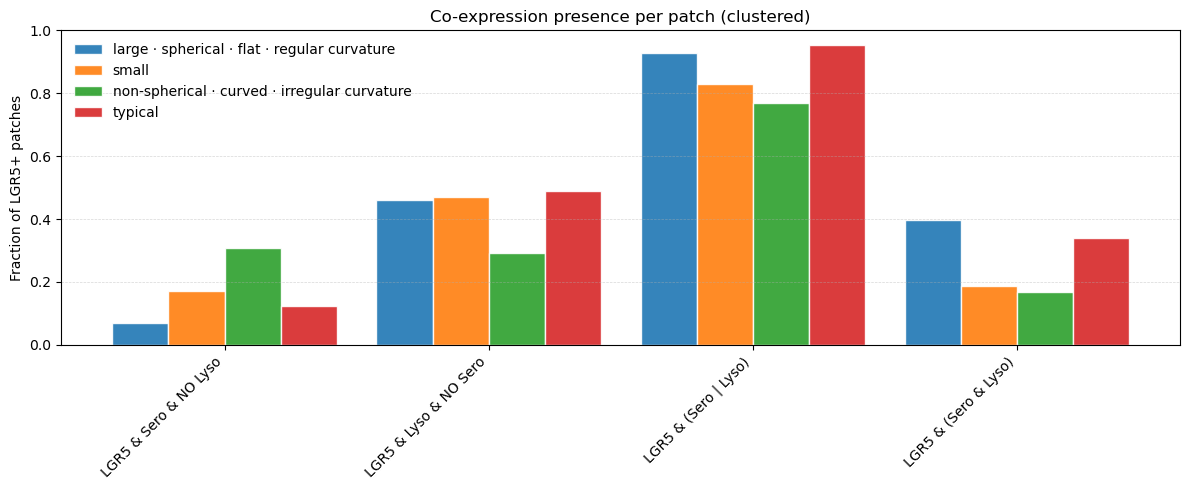

In [ ]:
# --- Condition labels (order must match your coexpression vector) ---
labels_cond = [
    "LGR5 & Sero & NO Lyso",
    "LGR5 & Lyso & NO Sero",
    "LGR5 & (Sero | Lyso)",
    "LGR5 & (Sero & Lyso)",
]

# --- Cluster labels for legend ---
if 'cluster_name' in clustered_df.columns:
    name_map = (
        clustered_df[['cluster','cluster_name']]
        .drop_duplicates()
        .set_index('cluster')['cluster_name']
        .to_dict()
    )
    cluster_labels = [name_map.get(c, f"Cluster {c}") for c in clusters_sorted]
else:
    cluster_labels = [f"Cluster {c}" for c in clusters_sorted]

K = len(clusters_sorted)
x = np.arange(len(labels_cond))

# Bar layout: K bars per condition
group_width = 0.85
w = group_width / max(1, K)
offsets = (np.arange(K) - (K - 1)/2) * w

# Denominator: number of LGR5+ patches per cluster
i_LGR5 = marker_names.index("LGR5")

plt.figure(figsize=(max(12, 0.7*len(labels_cond)), 5))

for ki in range(K):
    denom = float(marker_pos_crypt_cluster[ki, i_LGR5])
    vals = np.divide(
        coexpression_crypt_cluster[ki, :],
        denom,
        out=np.zeros(len(labels_cond), dtype=float),
        where=(denom > 0)
    )
    plt.bar(x + offsets[ki], vals, width=w, label=cluster_labels[ki],
            edgecolor="white", alpha=0.9)

plt.xticks(x, labels_cond, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Fraction of LGR5+ patches")
plt.title("Co-expression presence per patch (clustered)")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
